# Separación del conjunto de proteínas en positivas y negativas

Vamos a hacer primero una distribución gráfica de todos nuestros datos y luego a reevaluar si el umbral que hemos puesto es correcto o no.

Cargamos los datos.

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

interactions = pd.read_csv("Interacciones_EffectorProteina_LiteratureOnly_Ordenadas_NleG.csv")
interactions.head()

,Effector,Protein,ProteinGeneName,Shared_Connections,Shortest_Path,Is_Connected
0,EspL,O89110,Casp8,4,1.0,True
1,EspL,Q60855,Ripk1,3,1.0,True
2,NleB,O89110,Casp8,2,1.0,True
3,NleA,Q8R4B8,Nlrp3,1,1.0,True
4,NleA,Q9D8T2,Gsdmd,1,1.0,True


In [34]:
# Función de dibujo de las distribuciones de grupos entre parejas positivas y negativas
def draw_group_distribution(pos_groups_freq, neg_groups_freq, figure_name='distribucion_grupos_pos_neg_train.png', pos_color='green', neg_color='red',
                           title='Interacciones entre grupos representadas en positive y negative train sets', x_label='Grupos interaccionando'):
    
    # Unfy them in one unique data frame
    df_plot = pd.DataFrame({
        'Positivas': pos_groups_freq,
        'Negativas': neg_groups_freq
    }).fillna(0)
    
    df_plot = df_plot.sort_values(by='Positivas', ascending=False)
    
    # Draw the two distributions as a histogram
    plt.figure(figsize=(20, 10))
    x = range(len(df_plot))
    width = 0.4
    plt.bar(x, df_plot['Positivas'], width=width, label='Positivas', color=pos_color, alpha=0.5)
    plt.bar([i + width for i in x], df_plot['Negativas'], width=width, label='Negativas', color=neg_color)
    plt.xticks([i + width/2 for i in x], df_plot.index, rotation=90, size=10)
    #plt.yticks(np.arange(min(df_plot['Negativas']), max(df_plot['Positivas'])+1, 2)) 
    plt.title(title, size=25)
    plt.xlabel(x_label, size=20)
    plt.ylabel('Frecuencia', size=20)
    plt.legend(fontsize=20)
    plt.grid(axis='y', alpha=0.5)
    plt.savefig(figure_name, dpi=300, bbox_inches='tight')
    plt.show()

Hacemos el dibujo.

In [35]:
# # Separo las interacciones positivas de las negativas
# q2 = round(217 + (5472 - 217)*0.5)
# positivas = interactions[0:217]
# negativas = interactions[q2:len(interactions)]
# resto = interactions[217:q2]

# # Gráfico de dispersión
# plt.figure(figsize=(10, 6)) # Opcional: define el tamaño de la ventana
# plt.scatter(positivas['Shared_Connections'], positivas['Shortest_Path'], label='Interacciones positivas', color='seagreen')
# plt.scatter(negativas['Shared_Connections'], negativas['Shortest_Path'], label='Interacciones negativas', color='red')
# plt.scatter(resto['Shared_Connections'], resto['Shortest_Path'], label='Interacciones desconocidas', color='grey')
# plt.hlines(y=[5.5, 1.52, 3], xmin=0, xmax=21, colors=['r', 'g'], linestyles=['--', '--'])
# plt.title('Relación entre Shared Connections y Shortest Path')
# plt.xlabel('Shared Connections')
# plt.ylabel('Shortest Path')
# plt.legend()
# plt.grid(True) 
# plt.savefig('separacion_pos_neg.png', dpi=300)
# plt.show()

In [36]:
# # Separo las interacciones positivas de las negativas
# q2 = round(217 + (5472 - 217)*0.5)
# q2=2801
# positivas = interactions[0:217]
# negativas = interactions[q2:len(interactions)]
# resto = interactions[217:q2]
# interactions['id_fila'] = pd.Series(range(len(interactions))).values

# # Gráfico de barras
# fig, ax = plt.subplots()
# # Definimos los umbrales de separación de positivos y negativos
# plt.vlines(x=[217, q2], ymin=0, ymax=21, colors=['g', 'r'], linestyles=['--', '--'], alpha=0)
# # Dividimos el gráfico en zonas de positivos y negativos y lo coloreamos
# ax.axvspan(0, 217, color='green', alpha=0.3, label='Zona Positivos', edgecolor='none', linewidth=0)
# ax.axvspan(217, q2, color='gray', alpha=0.3, label='Zona desconocida', edgecolor='none', linewidth=0)
# ax.axvspan(q2, len(interactions), color='red', alpha=0.3, label='Zona Negativos', edgecolor='none', linewidth=0)
# # Dibujamos las distribuciones
# ax.bar(interactions['id_fila'], interactions['Shortest_Path'], label='Shortest Path', color='orange', width=1.0, edgecolor='none')
# ax.bar(interactions['id_fila'], interactions['Shared_Connections'], bottom=interactions['Shortest_Path'], label='Shared Connections', color='blue', width=1.0, edgecolor='none')
# plt.title('Relación entre Shared Connections y Shortest Path')
# plt.ylabel('Shared Connections y Shortest Path')
# plt.xlabel('Proteínas')
# plt.legend(loc='upper right', fontsize='small')
# plt.savefig('separacion_pos_neg_barplot.png', dpi=600, bbox_inches='tight')
# plt.show()

Repetimos con el nuevo csv de interacciones ordenados por un índice de mayor probabilidad de interacción calculado a partir del grafo extendido.

In [37]:
new_interactions = pd.read_csv("Interacciones_EffectorProteina_LiteratureExtended_Ordenadas.csv", sep=';')
new_interactions.head()
new_interactions

,Effector,Protein,Shortest_Path,Shared_Connections,Pathways_Shared,Is_Connected,Interaction_Score
0,NleD,Mapk14,1,13,1,True,0.603571
1,EspM,Rhoc,1,3,3,True,0.539286
2,NleB,Ripk1,1,13,0,True,0.528571
3,NleB,Nfkb1,1,2,3,True,0.517857
4,EspH,Rac2,1,2,3,True,0.517857
...,...,...,...,...,...,...,...
5125,NleG8,Tmbim6,6,0,0,False,0.000000
5126,NleG8,Rab17,6,0,0,False,0.000000
5127,NleG8,Rab11b,6,0,0,False,0.000000
5128,NleG8,Rab11fip3,6,0,0,False,0.000000


Ordenamos los valores según la columna de Interaction Score.

In [38]:
# new_interactions = new_interactions.sort_values(by='Interaction_Score', ascending=False, kind='stable')
# new_interactions.to_csv("Interacciones_EffectorProteina_LiteratureExtended_Ordenadas_NleG_IS.csv", index=False)

Reseteamos los índices y eliminamos todas las parejas positivas.

In [39]:
new_interactions_no_pos = new_interactions[new_interactions['Is_Connected']==False]
new_interactions_no_pos = new_interactions_no_pos.reset_index(drop=True)
new_interactions_no_pos.to_csv("Interacciones_EffectorProteina_LiteratureExtended_Ordenadas_no_pos.csv", index=False)
new_interactions_no_pos

,Effector,Protein,Shortest_Path,Shared_Connections,Pathways_Shared,Is_Connected,Interaction_Score
0,NleD,Map3k7,2,21,1,False,0.725
1,NleD,Il6,2,21,1,False,0.725
2,NleD,Jun,2,21,1,False,0.725
3,NleD,Ccl8,2,21,0,False,0.650
4,NleD,Ccl28,2,21,0,False,0.650
...,...,...,...,...,...,...,...
4908,NleG8,Tmbim6,6,0,0,False,0.000
4909,NleG8,Rab17,6,0,0,False,0.000
4910,NleG8,Rab11b,6,0,0,False,0.000
4911,NleG8,Rab11fip3,6,0,0,False,0.000


/tmp/ipykernel_1336/595818526.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(0, q2, color='gray', alpha=0.3, label='Zona desconocida', edgecolor='none', linewidth=0)
/tmp/ipykernel_1336/595818526.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(q2, len(new_interactions_no_pos), color='red', alpha=0.3, label='Zona Negativos', edgecolor='none', linewidth=0)


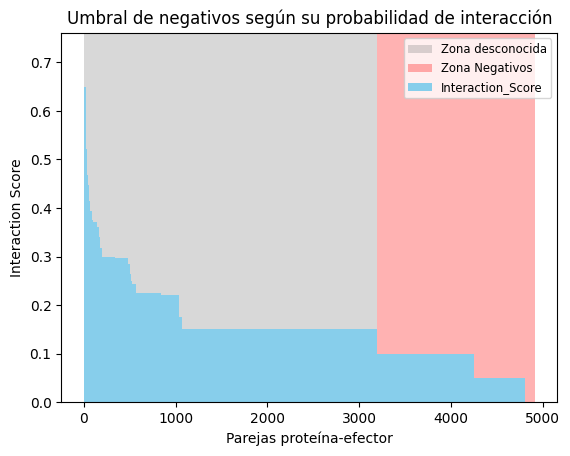

In [40]:
# Separo las interacciones positivas de las negativas
q2 = round((5130 - 217)*0.5)
q2 = 3194
negativas = new_interactions_no_pos[q2:len(new_interactions_no_pos)]
resto = new_interactions_no_pos[0:q2]
new_interactions_no_pos['id_fila'] = pd.Series(range(len(new_interactions_no_pos))).values

# Gráfico de barras
fig, ax = plt.subplots()
# Definimos los umbrales de separación de positivos y negativos
plt.vlines(x=[q2], ymin=0, ymax=0.7, colors=['r'], linestyles=['--'], alpha=0)
# Dividimos el gráfico en zonas de inciertos y negativos y lo coloreamos
ax.axvspan(0, q2, color='gray', alpha=0.3, label='Zona desconocida', edgecolor='none', linewidth=0)
ax.axvspan(q2, len(new_interactions_no_pos), color='red', alpha=0.3, label='Zona Negativos', edgecolor='none', linewidth=0)
# Dibujamos las distribuciones
ax.bar(new_interactions_no_pos['id_fila'], new_interactions_no_pos['Interaction_Score'], label='Interaction_Score', color='skyblue', width=1.0, edgecolor='none')
plt.title('Umbral de negativos según su probabilidad de interacción')
plt.ylabel('Interaction Score')
plt.xlabel('Parejas proteína-efector')
plt.legend(loc='upper right', fontsize='small')
#plt.savefig('separacion_pos_neg_index_barplot.png', dpi=600, bbox_inches='tight')
plt.show()

### Representación gráfica de las interacciones positivas

In [41]:
# Función para dibujar las frecuencias de aparición de un conjunto de nombres en un Data Frame de datos
def draw_freq(freq, title, xlabel, figure_name, font_size, title_size, ax_label_size):
    """ Función para dibujar frecuencias en formato de barplot.
    --freq: panda Series con dos columnas, nombre de los elementos a representar y frecuencia de cada uno
    --title: título del gráfico
    --xlabel: etiqueta del eje X
    --figure_name: nombre con el que se va a guardar el archivo .png con el gráfico
    --font_size: tamaño de fuente a usar en el eje X
    """
    freq = freq.sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    freq.plot.bar(color='green')
    plt.title(title, size=title_size)
    plt.xlabel(xlabel, size=ax_label_size)
    plt.ylabel('Frecuencia', size=ax_label_size)
    plt.xticks(fontsize=font_size)
    plt.grid(axis='y', alpha=0.5)
    plt.savefig(figure_name, dpi=300, bbox_inches='tight')
    plt.show()

##### Distribución de efectores individuales en el conjunto de parejas positivas

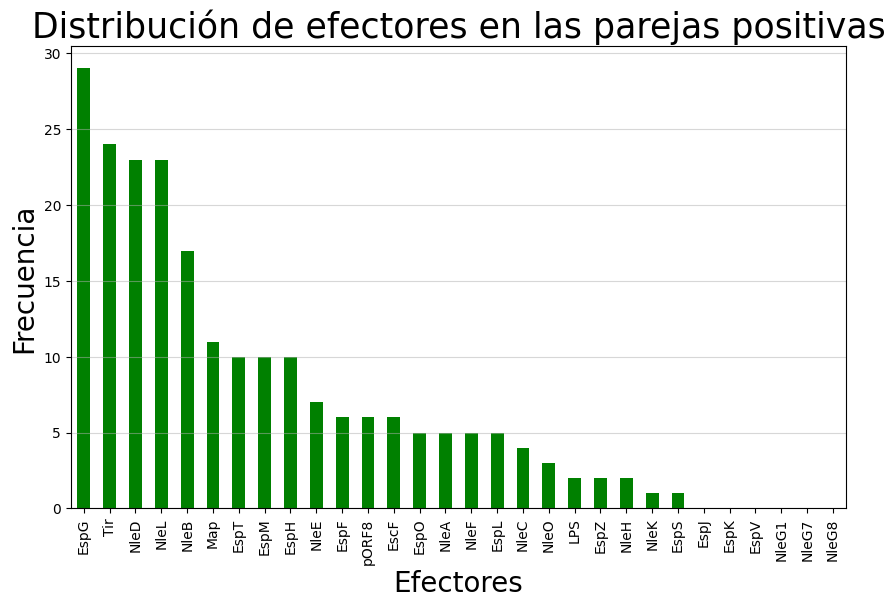

In [42]:
pos_interactions = new_interactions[new_interactions['Is_Connected']==True]
effectors = np.unique(new_interactions['Effector'])
freq_ef = pos_interactions['Effector'].value_counts()
freq_ef = freq_ef.reindex(effectors, fill_value=0)
draw_freq(freq_ef, 'Distribución de efectores en las parejas positivas', 'Efectores', 'distribucion_ef_pos_train.png', 10, 25, 20)

##### Distribución de proteínas individuales en el conjunto de parejas positivas

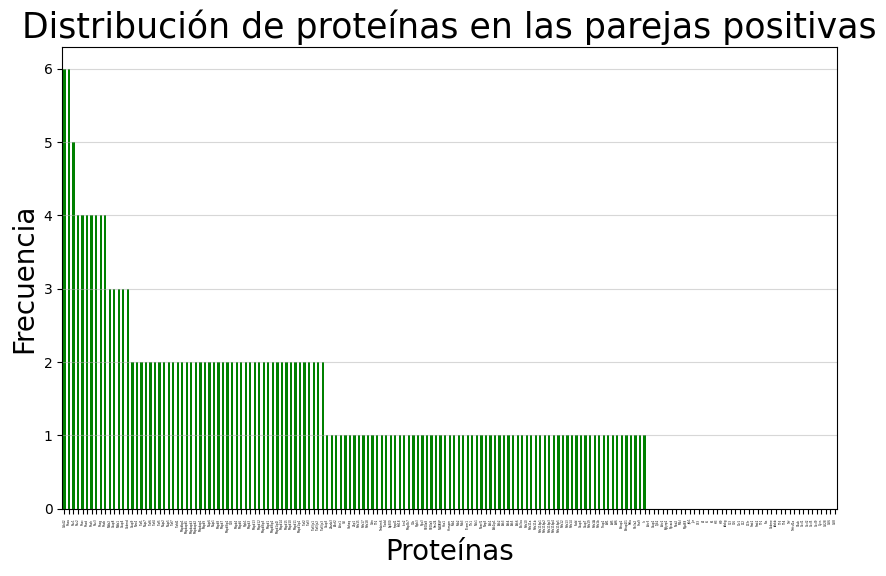

In [43]:
pos_interactions = new_interactions[new_interactions['Is_Connected']==True]
proteins = np.unique(new_interactions['Protein'])
freq_prot = pos_interactions['Protein'].value_counts()
freq_prot = freq_prot.reindex(proteins, fill_value=0)
draw_freq(freq_prot, 'Distribución de proteínas en las parejas positivas', 'Proteínas', 'distribucion_prot_pos_train.png', 2, 25, 20)

##### Distribución de grupos de efectores en el conjunto de parejas positivas

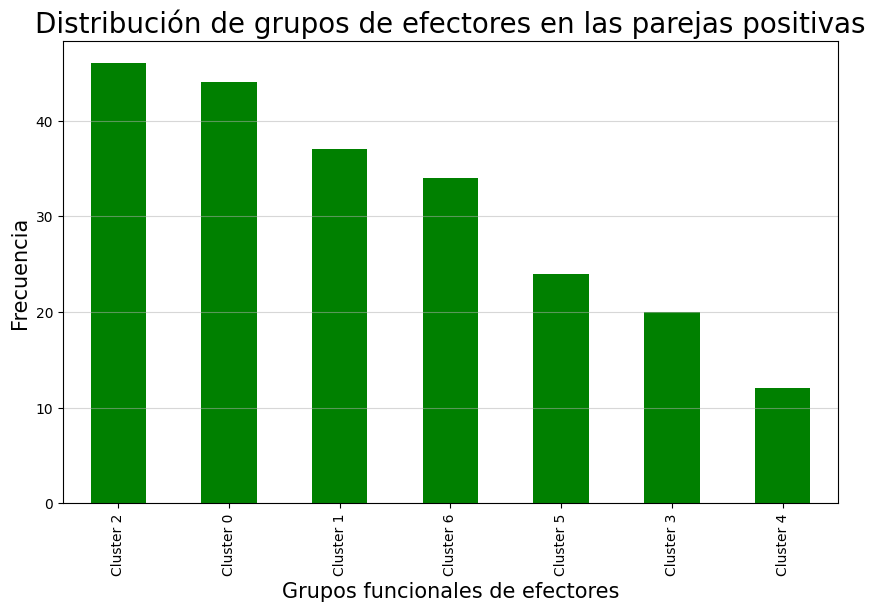

In [44]:
effector_groups = pd.read_csv("effector_groups_function.csv")
mapping_ef_groups = effector_groups.set_index("Effector")["effector_group"]
new_interactions["Effector_Group"] = new_interactions["Effector"].map(mapping_ef_groups)
new_interactions = new_interactions[new_interactions["Effector_Group"] != "-"]
pos_interactions = new_interactions[new_interactions['Is_Connected']==True]
unique_ef_groups = np.unique(new_interactions['Effector_Group'])
freq_ef_group = pos_interactions['Effector_Group'].value_counts()
freq_ef_group = freq_ef_group.reindex(unique_ef_groups, fill_value=0)
draw_freq(freq_ef_group, 'Distribución de grupos de efectores en las parejas positivas', 'Grupos funcionales de efectores', 'distribucion_grupos_ef_pos_train.png', 10, 20, 15)

##### Distribución de grupos de proteínas en el conjunto de parejas positivas

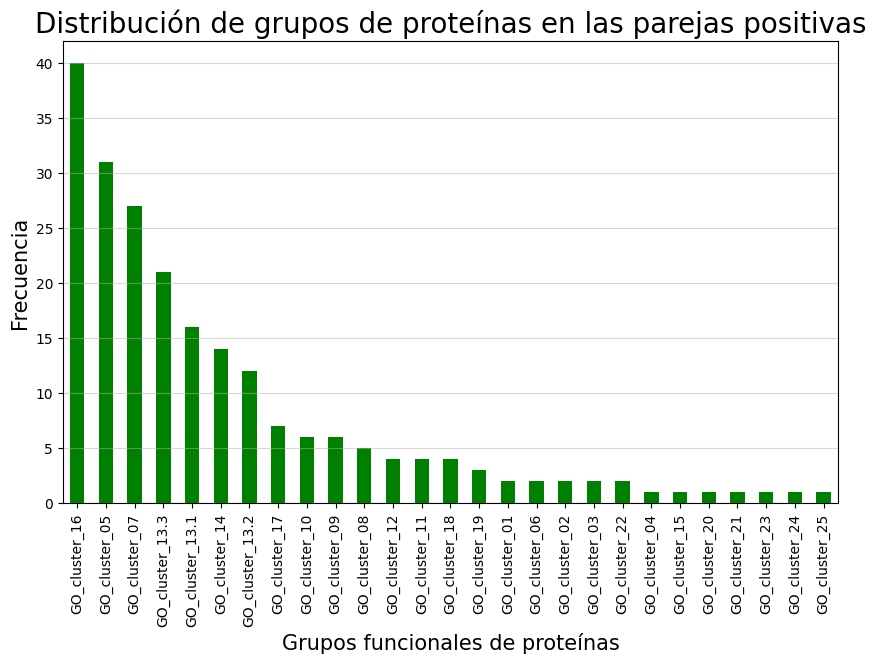

In [45]:
protein_groups = pd.read_csv("protein_go_80_clusters_grupo13sep.csv")
mapping_prot_groups = protein_groups.set_index("gene_name")["protein_group"]
new_interactions["Protein_Group"] = new_interactions["Protein"].map(mapping_prot_groups)
new_interactions["Protein_Group"] = new_interactions["Protein_Group"].fillna("Sin_Grupo")
new_interactions = new_interactions[new_interactions["Protein_Group"] != "Sin_Grupo"]
pos_interactions = new_interactions[new_interactions['Is_Connected']==True]
unique_prot_groups = np.unique(new_interactions['Protein_Group'])
freq_prot_group = pos_interactions['Protein_Group'].value_counts()
freq_prot_group = freq_prot_group.reindex(unique_prot_groups, fill_value=0)
draw_freq(freq_prot_group, 'Distribución de grupos de proteínas en las parejas positivas', 'Grupos funcionales de proteínas', 'distribucion_grupos_prot_pos_train_g13sep.png', 10, 20, 15)

# Heatmap

Llamamos al código con el heatmap y lo ejecutamos primero con unos datos de prueba para ver si funciona correctamente.

Dataset sintético: 306 parejas (133 pos, 173 neg)


/home/jovyan/TFG/plot_coverage_heatmap.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figura guardada en: /figura_ejemplo_coverage_heatmap.png

── Resumen de aptitud por escenario ──────────────────────────────
  C3  : 15 combinaciones aptas (verde)
  Train only: 14 combinaciones (naranja, ambas clases, <3)
  Inf. cualitativa: 41 combinaciones (rojo, solo 1 clase)
  Sin datos: 7 combinaciones (gris)
  C2E : 7/7 grupos de efector aptos
  C2P : 10/11 grupos de proteína aptos
  ⚠️  Grupos proteína NO aptos C2P: ['PG8']
──────────────────────────────────────────────────────────────────



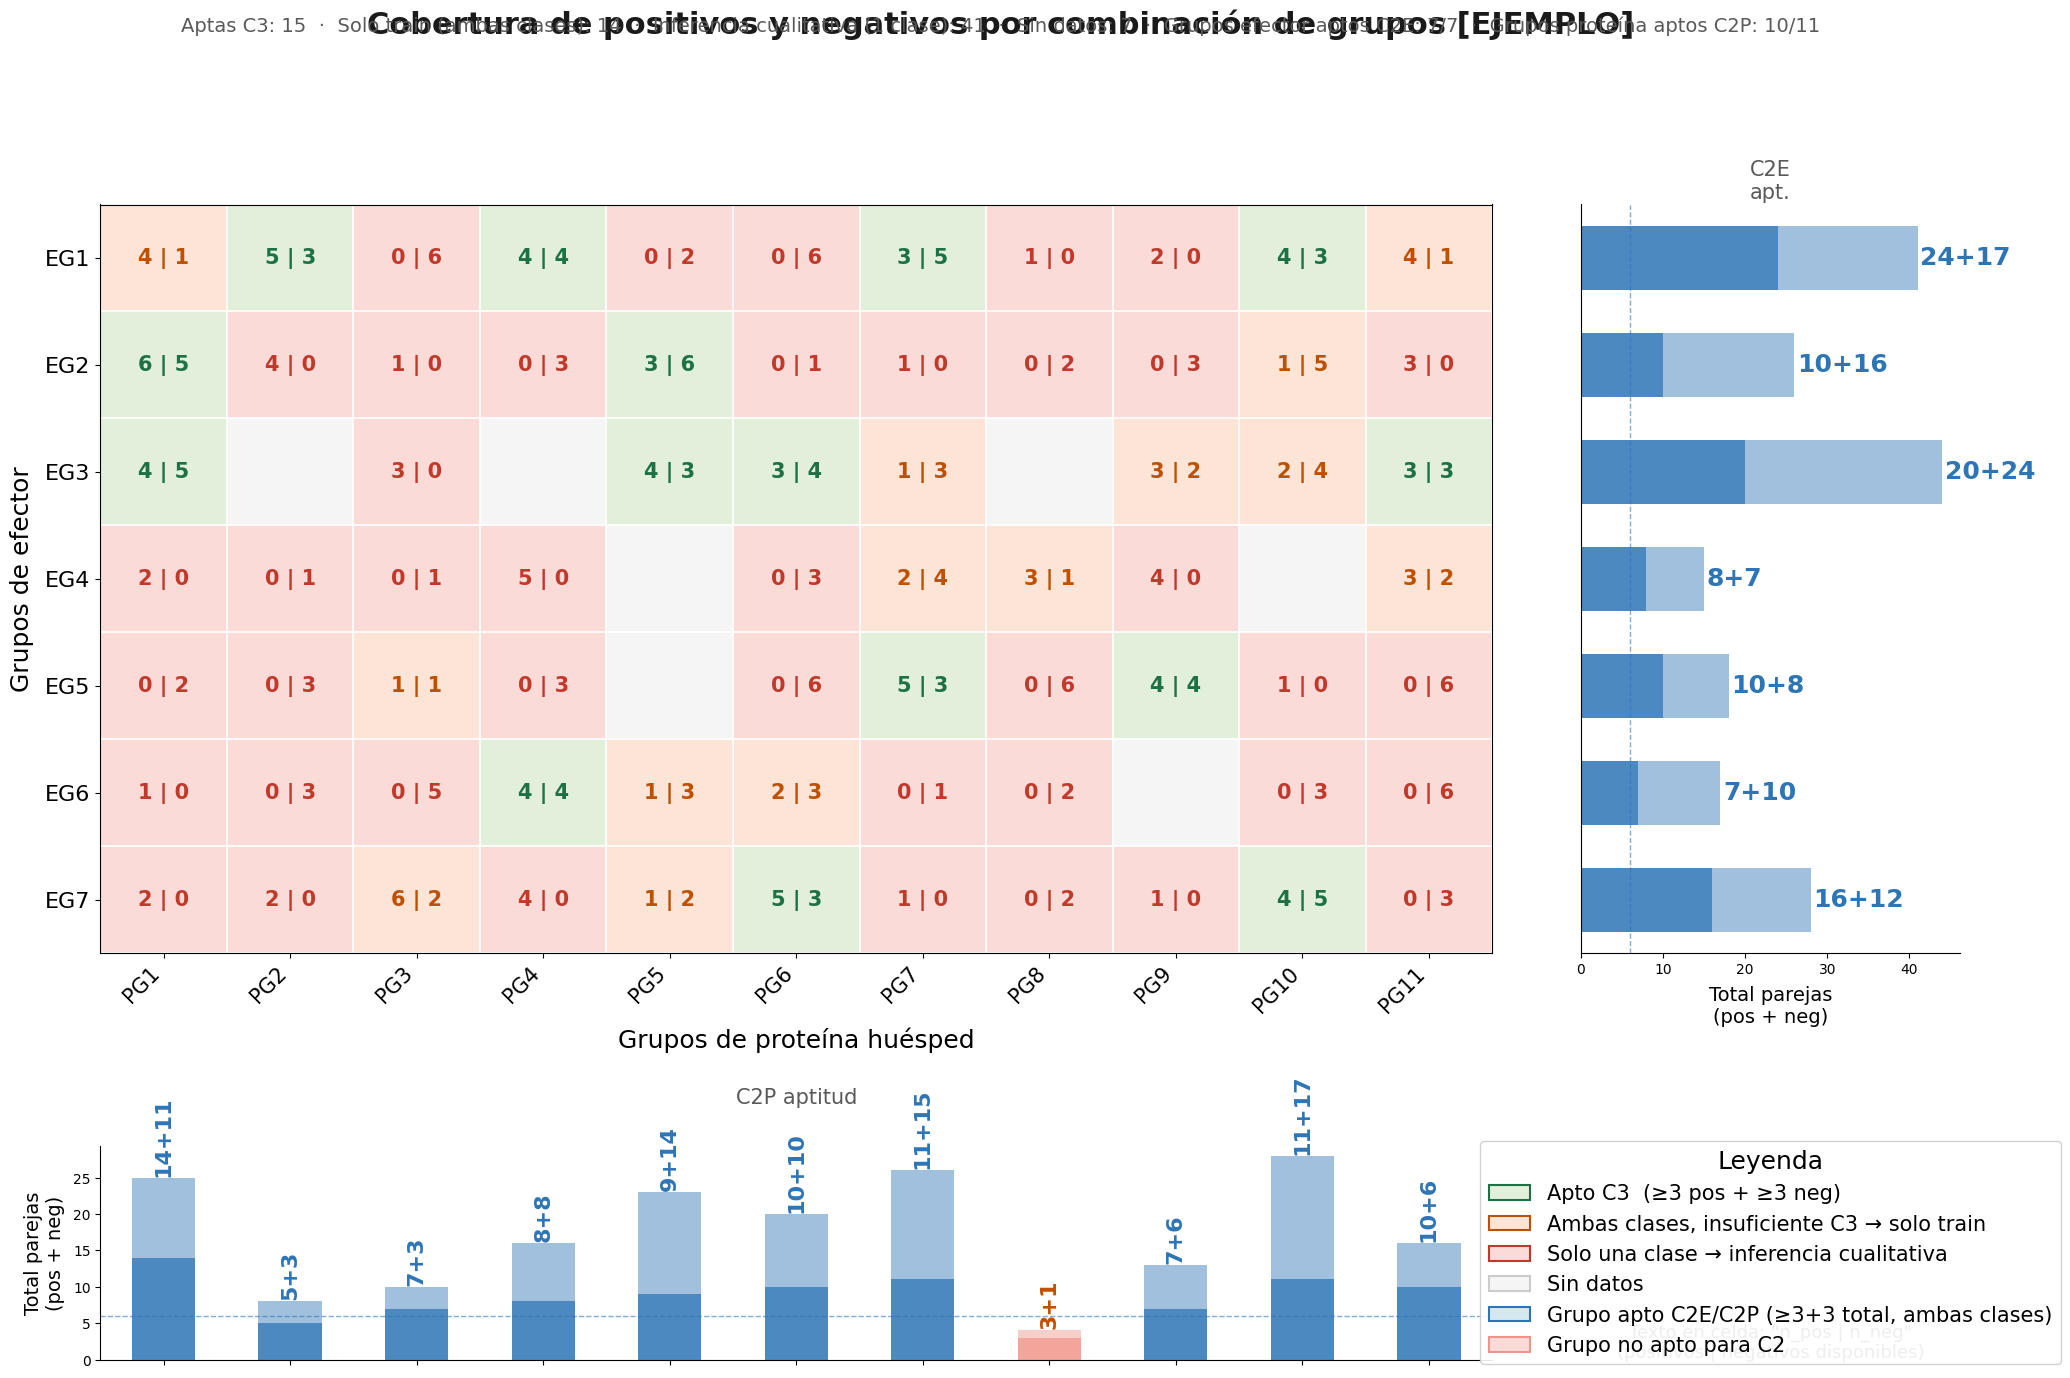

In [30]:
%run plot_coverage_heatmap.py

La ejecutamos ahora con nuestros datos.

/home/jovyan/TFG/plot_coverage_heatmap.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figura guardada en: heatmap_pos_neg_g13sep.png

── Resumen de aptitud por escenario ──────────────────────────────
  C3  : 7 combinaciones aptas (verde)
  Train only: 16 combinaciones (naranja, ambas clases, <3)
  Inf. cualitativa: 107 combinaciones (rojo, solo 1 clase)
  Sin datos: 59 combinaciones (gris)
  C2E : 4/7 grupos de efector aptos
  C2P : 6/27 grupos de proteína aptos
  ⚠️  Grupos efector NO aptos C2E: ['Cluster 0', 'Cluster 4', 'Cluster 5']
  ⚠️  Grupos proteína NO aptos C2P: ['GO_cluster_07', 'GO_cluster_16', 'GO_cluster_12', 'GO_cluster_11', 'GO_cluster_20', 'GO_cluster_17', 'GO_cluster_09', 'GO_cluster_13.2', 'GO_cluster_23', 'GO_cluster_19', 'GO_cluster_06', 'GO_cluster_01', 'GO_cluster_24', 'GO_cluster_15', 'GO_cluster_03', 'GO_cluster_22', 'GO_cluster_02', 'GO_cluster_21', 'GO_cluster_25', 'GO_cluster_18', 'GO_cluster_04']
──────────────────────────────────────────────────────────────────



(<Figure size 2400x1500 with 4 Axes>,
 (<Axes: xlabel='Grupos de proteína huésped', ylabel='Grupos de efector'>,
  <Axes: title={'center': 'C2E\napt.'}, xlabel='Total parejas\n(pos + neg)'>,
  <Axes: title={'center': 'C2P aptitud'}, ylabel='Total parejas\n(pos + neg)'>,
  <Axes: >),
 {'n_cells_C3_apt': 7,
  'n_cells_train_only': 16,
  'n_cells_one_class': 107,
  'n_cells_empty': 59,
  'n_effector_groups_C2E': 4,
  'n_protein_groups_C2P': 6,
  'effector_apt_C2E': ['Cluster 2', 'Cluster 1', 'Cluster 3', 'Cluster 6'],
  'effector_nonapt_C2E': ['Cluster 0', 'Cluster 4', 'Cluster 5'],
  'protein_apt_C2P': ['GO_cluster_13.3',
   'GO_cluster_14',
   'GO_cluster_05',
   'GO_cluster_13.1',
   'GO_cluster_08',
   'GO_cluster_10'],
  'protein_nonapt_C2P': ['GO_cluster_07',
   'GO_cluster_16',
   'GO_cluster_12',
   'GO_cluster_11',
   'GO_cluster_20',
   'GO_cluster_17',
   'GO_cluster_09',
   'GO_cluster_13.2',
   'GO_cluster_23',
   'GO_cluster_19',
   'GO_cluster_06',
   'GO_cluster_01',
   'G

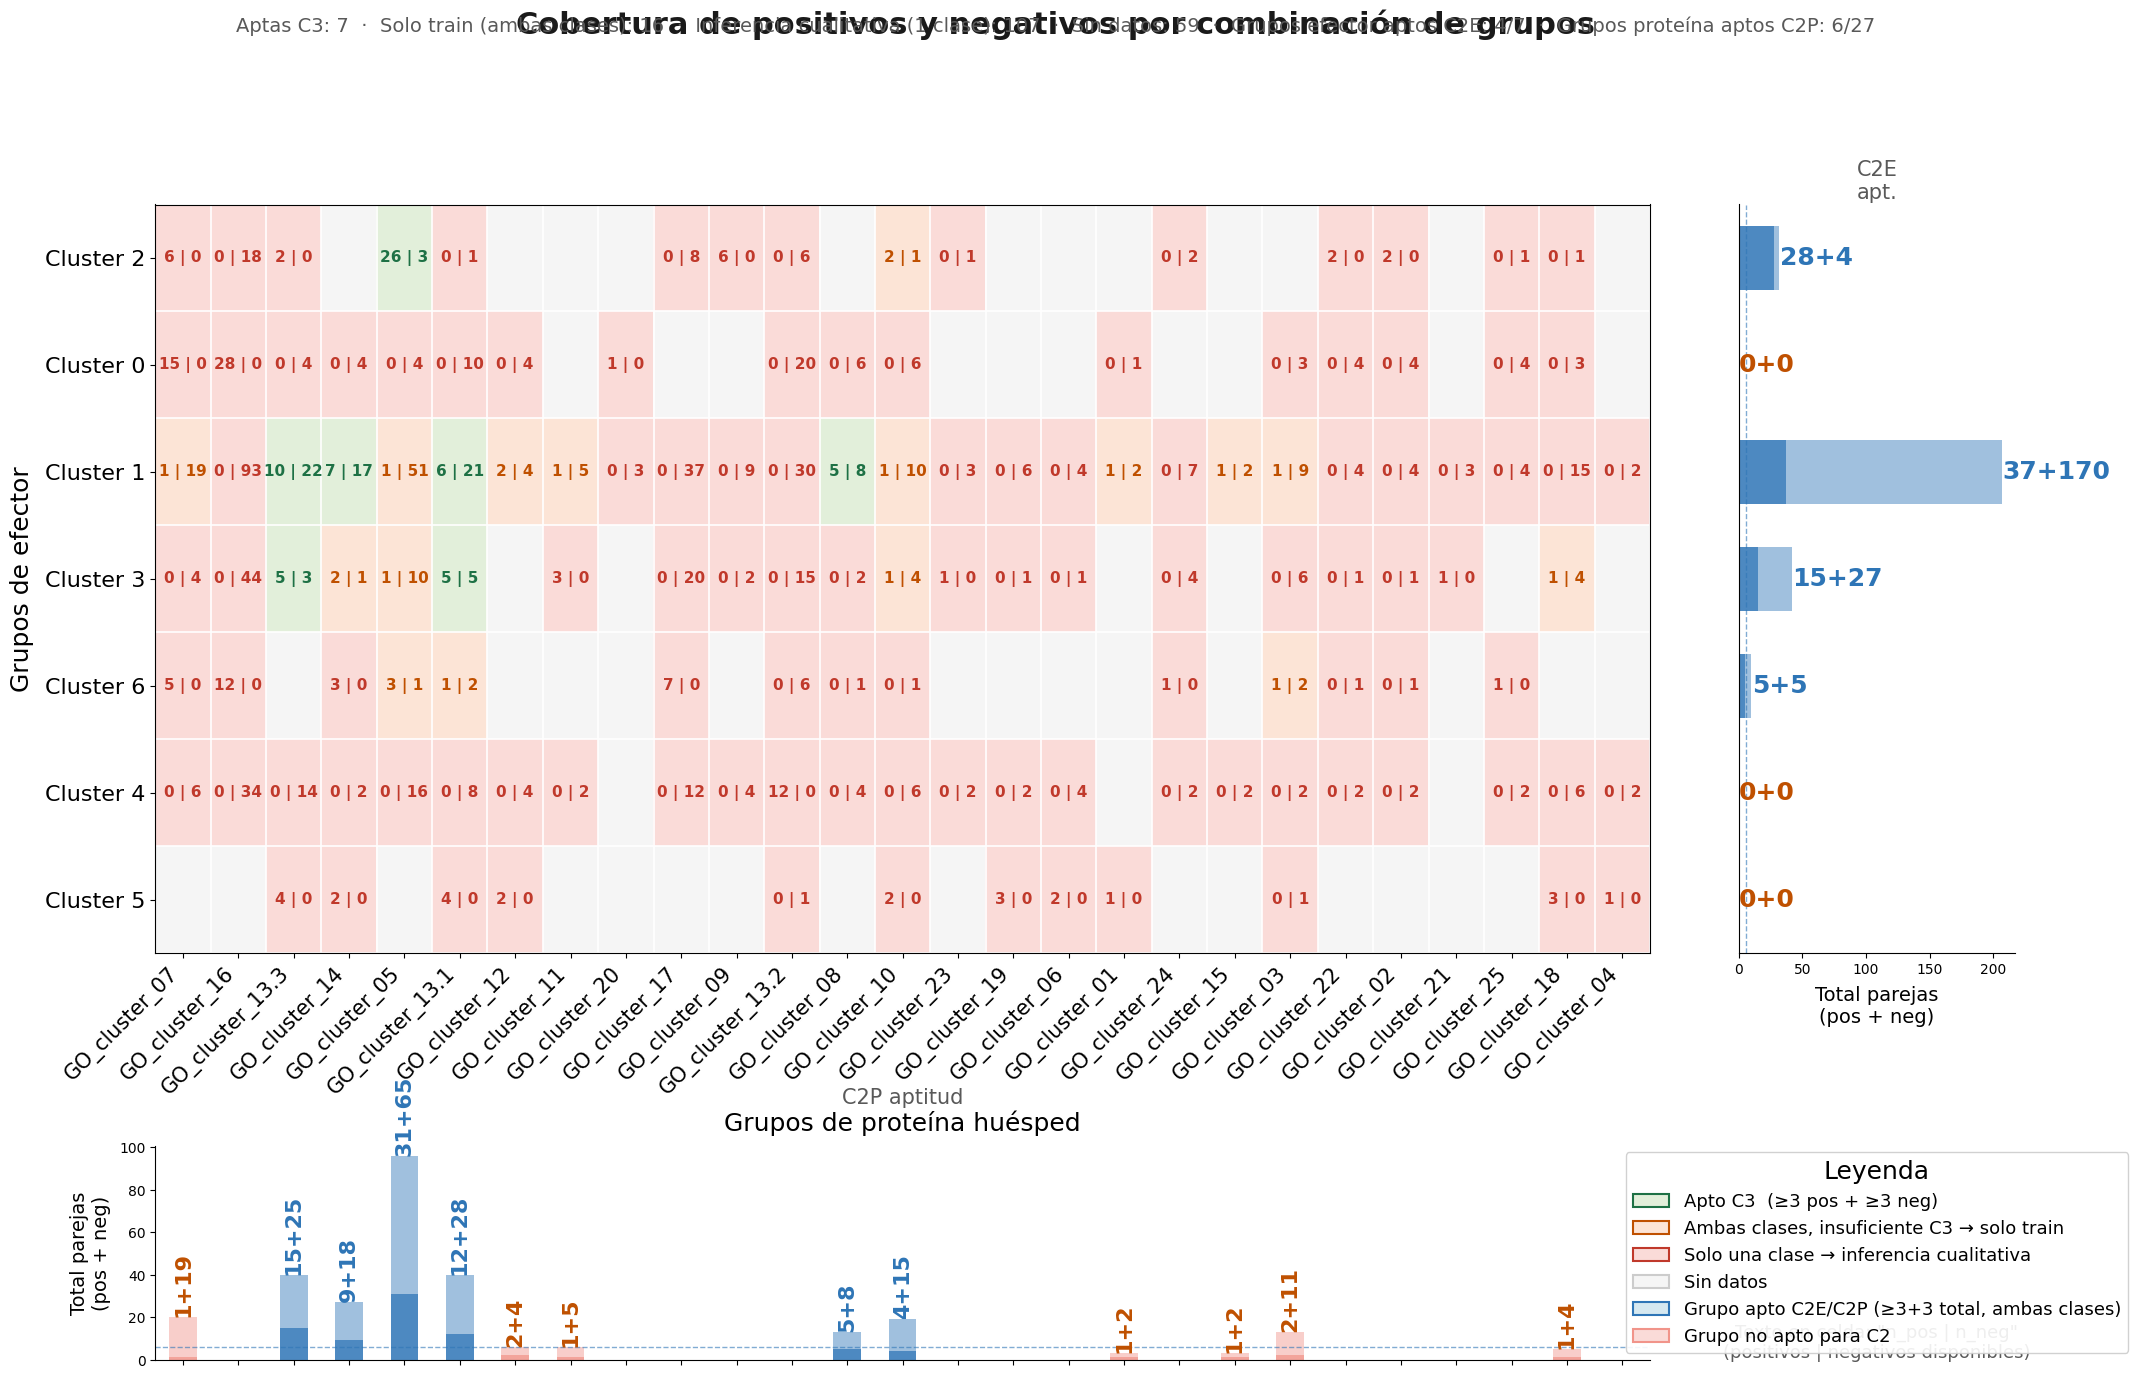

In [17]:
# Ya teníamos el dataframe con las interacciones positivas
# Añadimos las negativas definidas por el umbral
neg_interactions = new_interactions[new_interactions["Interaction_Score"] <= 0.1]
pos_neg_interactions = pd.concat([pos_interactions, neg_interactions])
pos_neg_interactions["Label"] = pos_neg_interactions["Is_Connected"].astype(int)

plot_coverage_heatmap(
    df=pos_neg_interactions, 
    effector_group_col="Effector_Group", 
    protein_group_col="Protein_Group",
    label_col="Label",
    save_path="heatmap_pos_neg_g13sep.png"
)

#### Distribución individual

In [13]:
%run plot_coverage_heatmap_distribuciones.py

/home/jovyan/TFG/plot_coverage_heatmap_distribuciones.py:414: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figura guardada en: heatmap_pos_neg_distribuciones.png

── Resumen de aptitud por escenario ──────────────────────────────
  C3  : 7 combinaciones aptas (verde)
  Train only: 16 combinaciones (naranja, ambas clases, <3)
  Inf. cualitativa: 107 combinaciones (rojo, solo 1 clase)
  Sin datos: 59 combinaciones (gris)
  C2E : 4/7 grupos de efector aptos
  C2P : 6/27 grupos de proteína aptos
  ⚠️  Grupos efector NO aptos C2E: ['Cluster 0', 'Cluster 4', 'Cluster 5']
  ⚠️  Grupos proteína NO aptos C2P: ['GO_cluster_07', 'GO_cluster_16', 'GO_cluster_12', 'GO_cluster_11', 'GO_cluster_20', 'GO_cluster_17', 'GO_cluster_09', 'GO_cluster_13.2', 'GO_cluster_23', 'GO_cluster_19', 'GO_cluster_06', 'GO_cluster_01', 'GO_cluster_24', 'GO_cluster_15', 'GO_cluster_03', 'GO_cluster_22', 'GO_cluster_02', 'GO_cluster_21', 'GO_cluster_25', 'GO_cluster_18', 'GO_cluster_04']
──────────────────────────────────────────────────────────────────



(<Figure size 3000x1800 with 134 Axes>,
 (<Axes: xlabel='Grupos de proteína huésped', ylabel='Grupos de efector'>,
  <Axes: title={'center': 'C2E\napt.'}, xlabel='Total parejas\n(pos + neg)'>,
  <Axes: title={'center': 'C2P aptitud'}, ylabel='Total parejas\n(pos + neg)'>,
  <Axes: >),
 {'n_cells_C3_apt': 7,
  'n_cells_train_only': 16,
  'n_cells_one_class': 107,
  'n_cells_empty': 59,
  'n_effector_groups_C2E': 4,
  'n_protein_groups_C2P': 6,
  'effector_apt_C2E': ['Cluster 2', 'Cluster 1', 'Cluster 3', 'Cluster 6'],
  'effector_nonapt_C2E': ['Cluster 0', 'Cluster 4', 'Cluster 5'],
  'protein_apt_C2P': ['GO_cluster_13.3',
   'GO_cluster_14',
   'GO_cluster_05',
   'GO_cluster_13.1',
   'GO_cluster_08',
   'GO_cluster_10'],
  'protein_nonapt_C2P': ['GO_cluster_07',
   'GO_cluster_16',
   'GO_cluster_12',
   'GO_cluster_11',
   'GO_cluster_20',
   'GO_cluster_17',
   'GO_cluster_09',
   'GO_cluster_13.2',
   'GO_cluster_23',
   'GO_cluster_19',
   'GO_cluster_06',
   'GO_cluster_01',
   

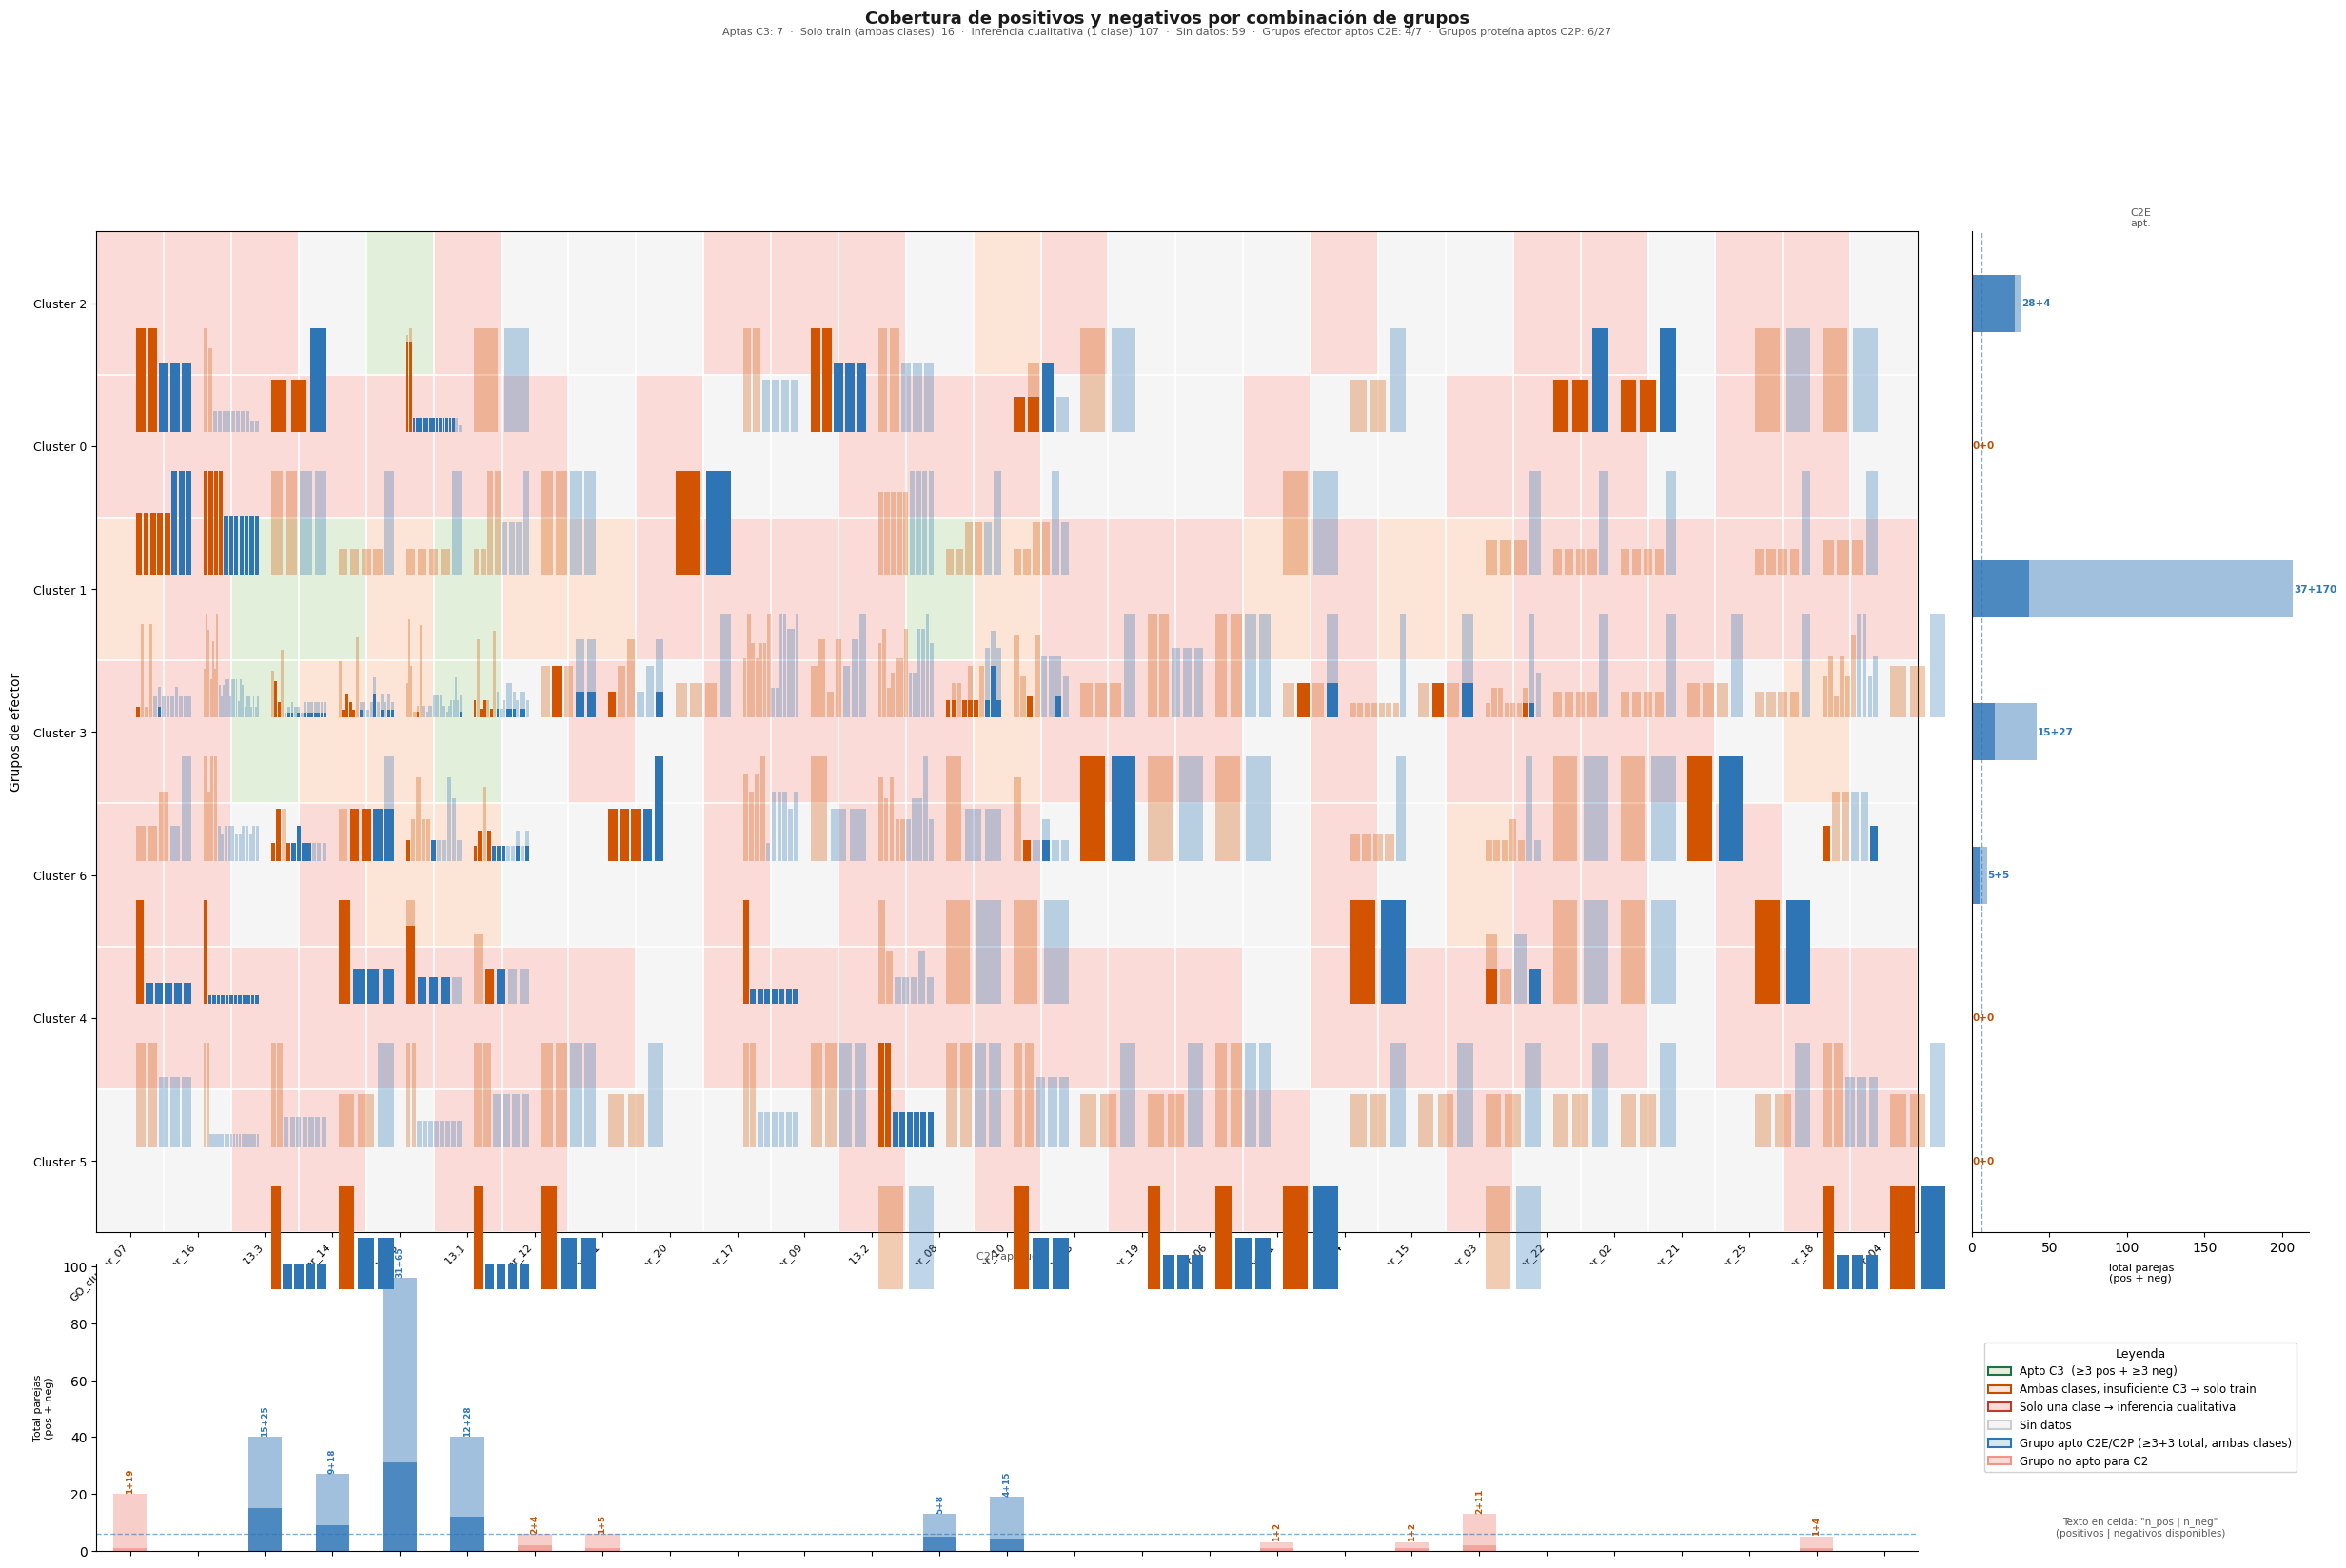

In [14]:
plot_coverage_heatmap_distributions(
    df=pos_neg_interactions,
    effector_col="Effector",
    protein_col="Protein",
    effector_group_col="Effector_Group",
    protein_group_col="Protein_Group",
    label_col="Label",
    min_C3=3,
    figsize=(30, 18),
    save_path="heatmap_pos_neg_distribuciones.png"
)

#### Distribución en el nivel C3 (cogemos verdes y naranjas)

In [46]:
# Obtenemos el conjunto de combinaciones que tienen positivos
pos_keys = set(pos_interactions.groupby(['Effector_Group', 'Protein_Group']).groups.keys())

# Obtenemos el conjunto de combinaciones que tienen negativos
neg_keys = set(neg_interactions.groupby(['Effector_Group', 'Protein_Group']).groups.keys())

# La INTERSECCIÓN son las celdas que tienen AL MENOS UNO de cada (Verde/Naranja)
mixed_cells = pos_keys.intersection(neg_keys)

print(f"Total de celdas mixtas encontradas: {len(mixed_cells)}")

# Filtrar Negativos
neg_interactions_c3 = neg_interactions[
    neg_interactions.apply(lambda x: (x['Effector_Group'], x['Protein_Group']) in mixed_cells, axis=1)
].copy()

# Filtrar Positivos
pos_interactions_c3 = pos_interactions[
    pos_interactions.apply(lambda x: (x['Effector_Group'], x['Protein_Group']) in mixed_cells, axis=1)
].copy()

train_interactions = pd.concat([pos_interactions_c3, neg_interactions_c3], ignore_index=True)

# 3. Verificación
print(f"Negativos originales: {len(neg_interactions)}")
print(f"Negativos en zonas Verde/Naranja: {len(neg_interactions_c3)}")
print(f"Positivos originales: {len(pos_interactions)}")
print(f"Positivos en zonas Verde/Naranja: {len(pos_interactions_c3)}")

Total de celdas mixtas encontradas: 23
Negativos originales: 798
Negativos en zonas Verde/Naranja: 206
Positivos originales: 217
Positivos en zonas Verde/Naranja: 85


Estos datos de entrenamiento del nivel C3 van a ser los mismos para el resto de niveles también, por lo que lo guardamos en un csv para poder acceder a ellos más tarde.

In [47]:
train_interactions.to_csv("Interacciones_Entrenamiento_CV_g13sep.csv", index=False)

##### Distribución de proteínas individuales en el Nivel C3

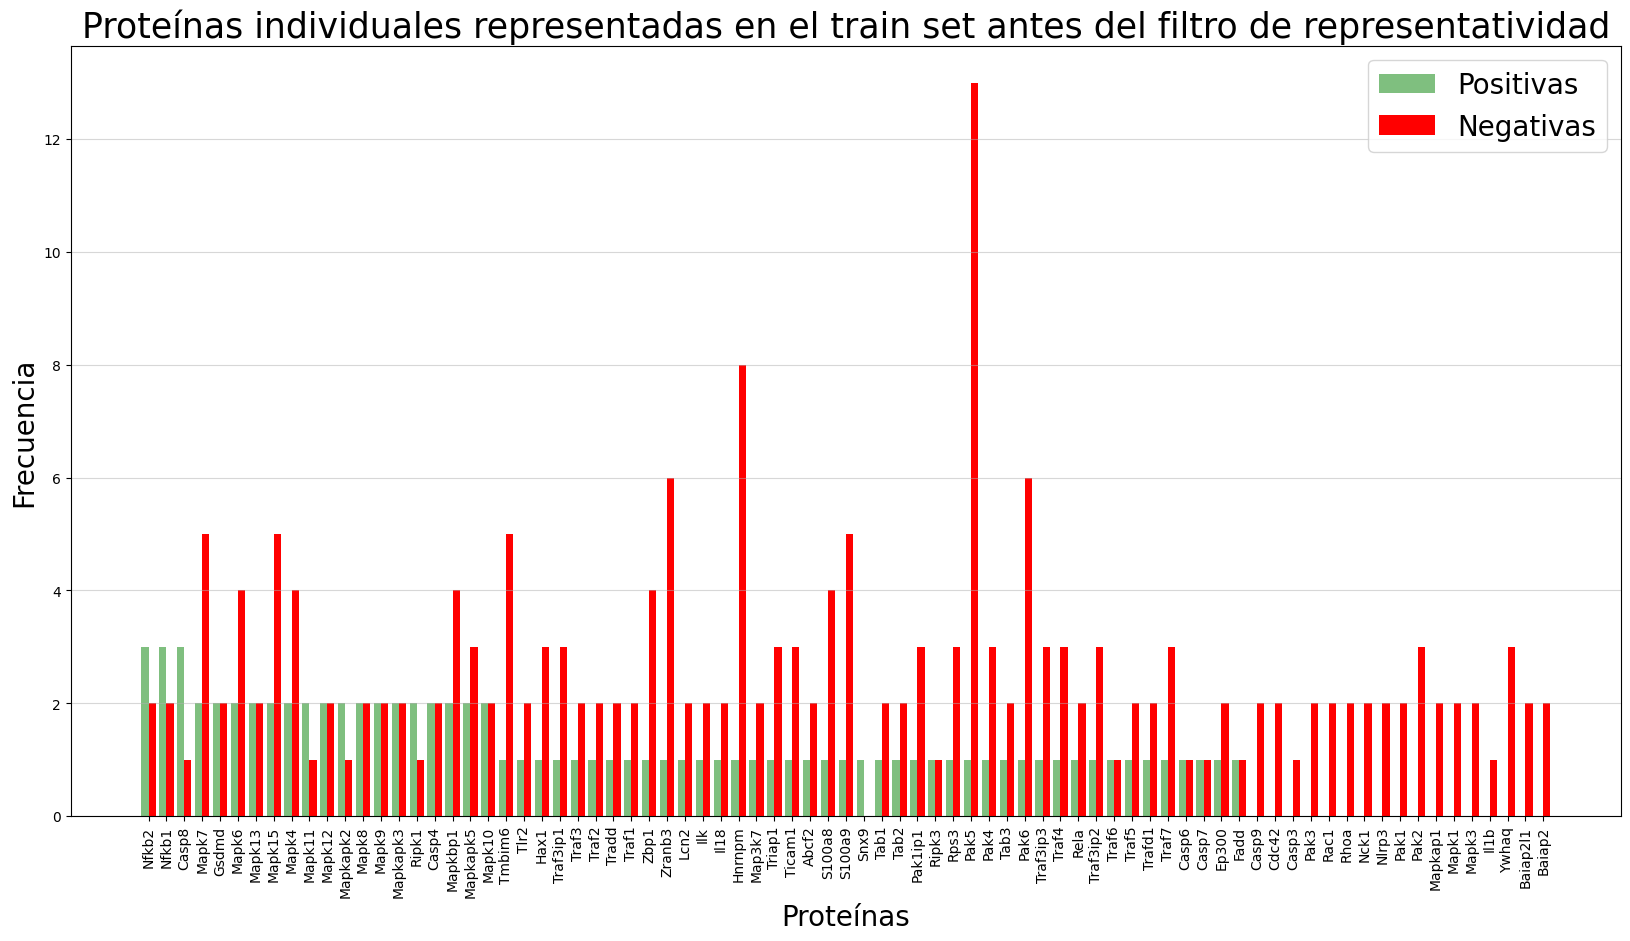

In [48]:
pos_prot_nivelc3 = pos_interactions_c3["Protein"]
neg_prot_nivelc3 = neg_interactions_c3["Protein"]
pos_prot_freq_nivelc3 = pos_prot_nivelc3.value_counts()
neg_prot_freq_nivelc3 = neg_prot_nivelc3.value_counts()
draw_group_distribution(pos_prot_freq_nivelc3, neg_prot_freq_nivelc3, 'distribucion_prot_pos_neg_train_nivelc3_g13sep.png', pos_color="green", neg_color="red", title="Proteínas individuales representadas en el train set antes del filtro de representatividad", x_label="Proteínas")

##### Distribución de efectores individuales en el Nivel C3

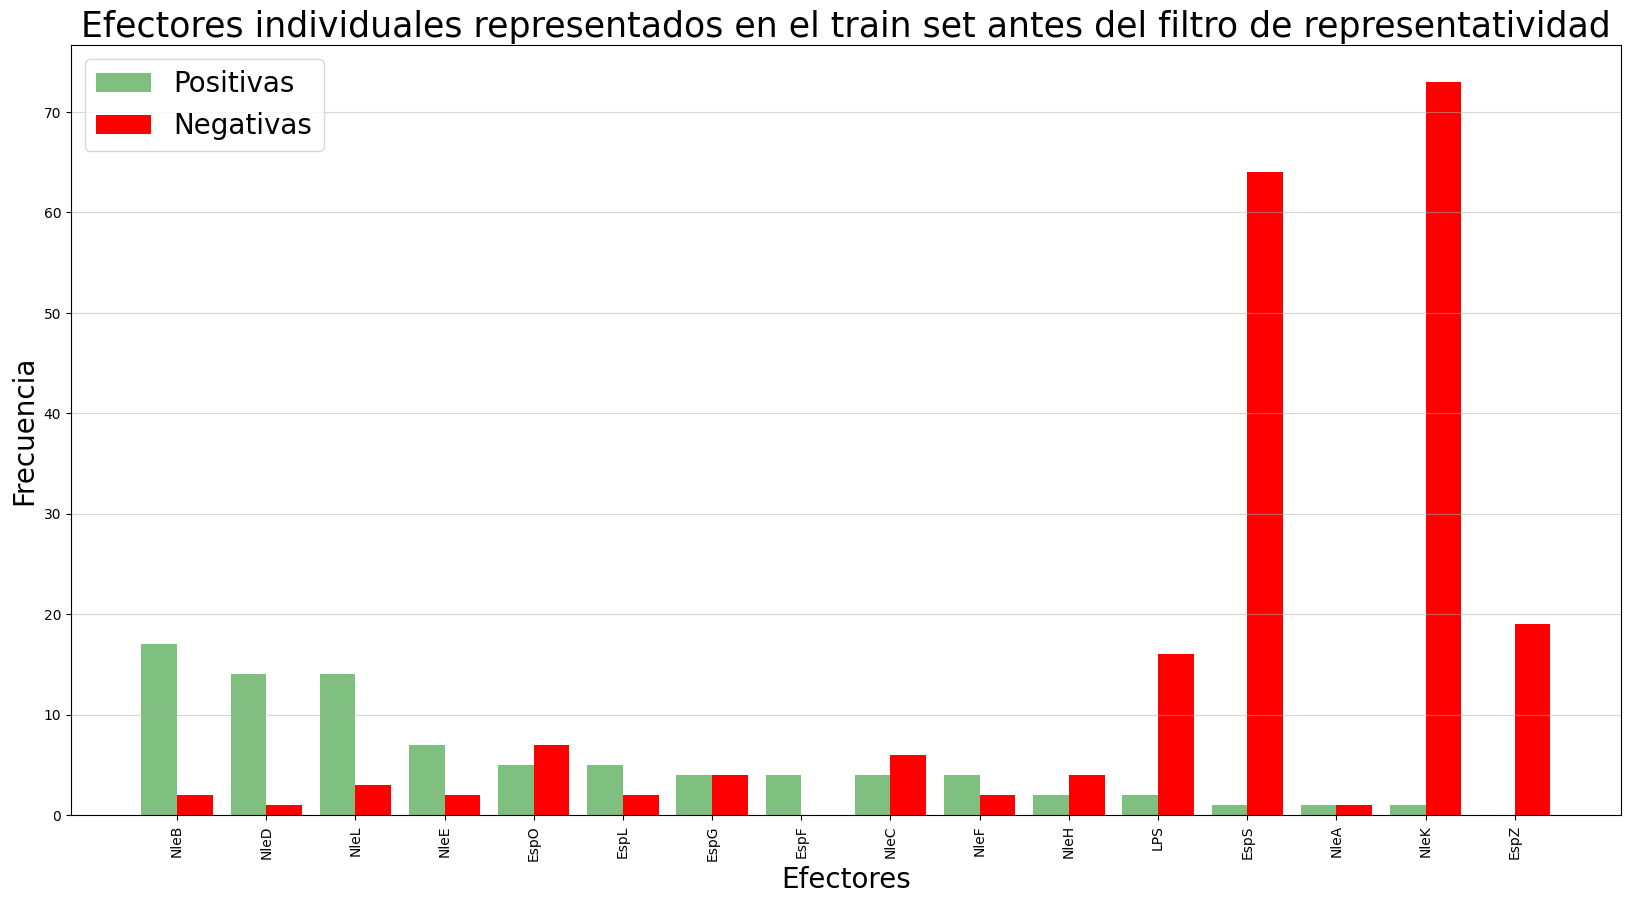

In [49]:
pos_ef_nivelc3 = pos_interactions_c3["Effector"]
neg_ef_nivelc3 = neg_interactions_c3["Effector"]
pos_ef_freq_nivelc3 = pos_ef_nivelc3.value_counts()
neg_ef_freq_nivelc3 = neg_ef_nivelc3.value_counts()
draw_group_distribution(pos_ef_freq_nivelc3, neg_ef_freq_nivelc3, 'distribucion_ef_pos_neg_train_nivelc3_g13sep.png', pos_color="green", neg_color="red", title="Efectores individuales representados en el train set antes del filtro de representatividad", x_label="Efectores")

#### Reajuste de datos para el nivel estricto

Nos quedamos con el nivel c3 (grupos de proteínas y efectores que al menos tienen una representación tanto en positivo como en negativo) y filtramos para que entre las celdas elegidas se eliminen todas aquellas parejas cuyos efectores o proteínas no aparezcan representadas individualmente en positivo y negativo.

In [50]:
# 1. Bucle de Estabilidad (Garantiza que Proteína Y Efector sean mixtos a la vez)
def filtrar_mixtos_estricto(df):
    pasada = 0
    while True:
        n_inicial = len(df)
        
        # Identificar quiénes tienen representación en AMBOS labels EN ESTE MOMENTO
        # Agrupamos y contamos cuántos labels únicos tiene cada uno (debe ser 2: 0 y 1)
        prot_counts = df.groupby('Protein')['Label'].nunique()
        ef_counts = df.groupby('Effector')['Label'].nunique()
        
        prot_mixtas = prot_counts[prot_counts == 2].index
        ef_mixtos = ef_counts[ef_counts == 2].index
        
        # Aplicar el filtro simultáneo
        df = df[df['Protein'].isin(prot_mixtas) & df['Effector'].isin(ef_mixtos)]
        
        pasada += 1
        n_final = len(df)
        print(f"Pasada {pasada}: {n_inicial} filas -> {n_final} filas")
        
        if n_inicial == n_final:
            print("✅ Estabilidad alcanzada. Todos los individuos son mixtos.")
            break
    return df

# Ejecutar el filtro
train_interactions["Label"] = train_interactions["Is_Connected"].astype(int)
pos_neg_interactions_estricto = filtrar_mixtos_estricto(train_interactions)

# 2. Extraer los subconjuntos usando LA MISMA VARIABLE FILTRADA
pos_interactions_estricto = pos_neg_interactions_estricto[pos_neg_interactions_estricto["Label"] == 1].copy()
neg_interactions_estricto = pos_neg_interactions_estricto[pos_neg_interactions_estricto["Label"] == 0].copy()

# 3. Verificación matemática (Si esto sale 0, es físicamente imposible que haya barras de un solo color)
solo_un_bando = pos_neg_interactions_estricto.groupby('Protein')['Label'].nunique()
print(f"Proteínas con un solo bando: {(solo_un_bando < 2).sum()}")

Pasada 1: 291 filas -> 237 filas
Pasada 2: 237 filas -> 233 filas
Pasada 3: 233 filas -> 233 filas
✅ Estabilidad alcanzada. Todos los individuos son mixtos.
Proteínas con un solo bando: 0


/home/jovyan/TFG/plot_coverage_heatmap.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figura guardada en: heatmap_pos_neg_nivelc3_g13sep.png

── Resumen de aptitud por escenario ──────────────────────────────
  C3  : 5 combinaciones aptas (verde)
  Train only: 12 combinaciones (naranja, ambas clases, <3)
  Inf. cualitativa: 5 combinaciones (rojo, solo 1 clase)
  Sin datos: 26 combinaciones (gris)
  C2E : 3/4 grupos de efector aptos
  C2P : 6/12 grupos de proteína aptos
  ⚠️  Grupos efector NO aptos C2E: ['Cluster 3']
  ⚠️  Grupos proteína NO aptos C2P: ['GO_cluster_12', 'GO_cluster_01', 'GO_cluster_15', 'GO_cluster_03', 'GO_cluster_11', 'GO_cluster_07']
──────────────────────────────────────────────────────────────────



(<Figure size 2400x1500 with 4 Axes>,
 (<Axes: xlabel='Grupos de proteína huésped', ylabel='Grupos de efector'>,
  <Axes: title={'center': 'C2E\napt.'}, xlabel='Total parejas\n(pos + neg)'>,
  <Axes: title={'center': 'C2P aptitud'}, ylabel='Total parejas\n(pos + neg)'>,
  <Axes: >),
 {'n_cells_C3_apt': 5,
  'n_cells_train_only': 12,
  'n_cells_one_class': 5,
  'n_cells_empty': 26,
  'n_effector_groups_C2E': 3,
  'n_protein_groups_C2P': 6,
  'effector_apt_C2E': ['Cluster 1', 'Cluster 2', 'Cluster 6'],
  'effector_nonapt_C2E': ['Cluster 3'],
  'protein_apt_C2P': ['GO_cluster_13.3',
   'GO_cluster_14',
   'GO_cluster_05',
   'GO_cluster_13.1',
   'GO_cluster_08',
   'GO_cluster_10'],
  'protein_nonapt_C2P': ['GO_cluster_12',
   'GO_cluster_01',
   'GO_cluster_15',
   'GO_cluster_03',
   'GO_cluster_11',
   'GO_cluster_07']})

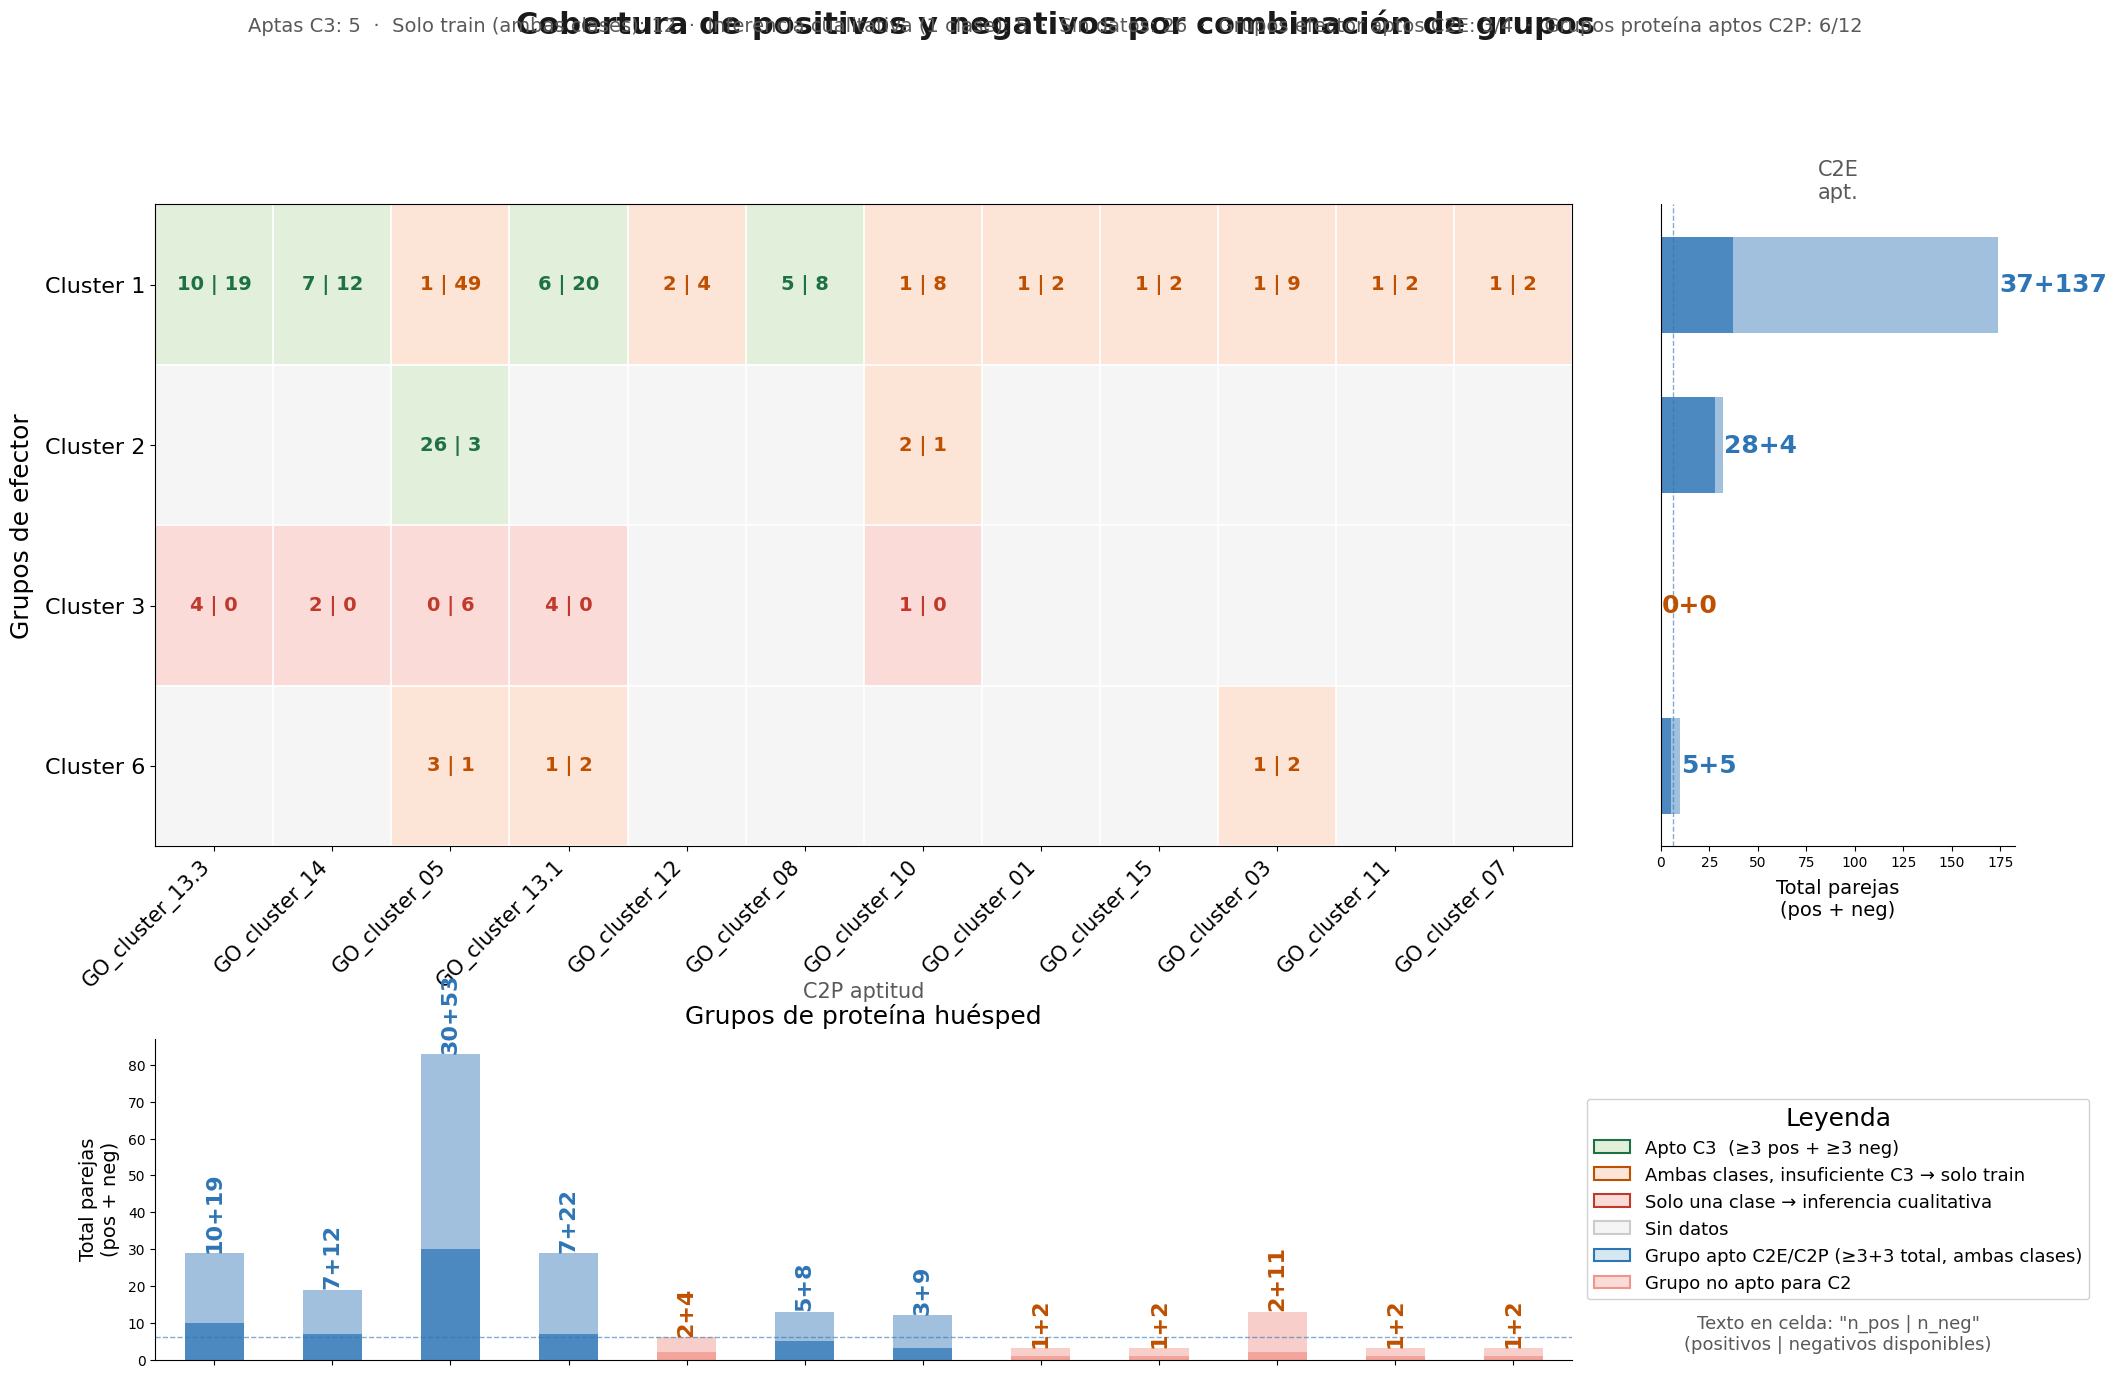

In [25]:
plot_coverage_heatmap(
    df=pos_neg_interactions_estricto, 
    effector_group_col="Effector_Group", 
    protein_group_col="Protein_Group",
    label_col="Label",
    save_path="heatmap_pos_neg_nivelc3_g13sep.png"
)

## Distribución en el Nivel C3 estricto

Buscamos quedarnos con las casillas verdes y naranjas de nuevo, pero esta vez esas casillas no incluirán proteínas ni efectores que no estén presentes tanto en positivo como en negativo. Sin embargo, al eliminar casillas rojas, puede ocurrir que se esté eliminando además la única pareja positiva de un determinado efector, por ejemplo. Por eso hay que hacer un filtro adicional que recorra las celdas y, si al eliminar una roja se ha eliminado el único representante de un tipo de una proteína o efector, que se elimine también su equivalente.

In [51]:
# Obtenemos el conjunto de combinaciones que tienen positivos
pos_keys = set(pos_interactions_estricto.groupby(['Effector_Group', 'Protein_Group']).groups.keys())

# Obtenemos el conjunto de combinaciones que tienen negativos
neg_keys = set(neg_interactions_estricto.groupby(['Effector_Group', 'Protein_Group']).groups.keys())

# La INTERSECCIÓN son las celdas que tienen AL MENOS UNO de cada (Verde/Naranja)
mixed_cells = pos_keys.intersection(neg_keys)

print(f"Total de celdas mixtas encontradas: {len(mixed_cells)}")

# Filtrar Negativos
neg_interactions_estricto = neg_interactions_estricto[
    neg_interactions_estricto.apply(lambda x: (x['Effector_Group'], x['Protein_Group']) in mixed_cells, axis=1)
].copy()

# Filtrar Positivos
pos_interactions_estricto = pos_interactions_estricto[
    pos_interactions_estricto.apply(lambda x: (x['Effector_Group'], x['Protein_Group']) in mixed_cells, axis=1)
].copy()

train_interactions_filtro_estricto = pd.concat([pos_interactions_estricto, neg_interactions_estricto], ignore_index=True)

# 3. Verificación
print(f"Negativos originales: {len(neg_interactions)}")
print(f"Negativos en zonas Verde/Naranja: {len(neg_interactions_estricto)}")
print(f"Positivos originales: {len(pos_interactions)}")
print(f"Positivos en zonas Verde/Naranja: {len(pos_interactions_estricto)}")

Total de celdas mixtas encontradas: 17
Negativos originales: 798
Negativos en zonas Verde/Naranja: 146
Positivos originales: 217
Positivos en zonas Verde/Naranja: 70


In [52]:
# Repetimos una función que nos vuelva a dejar solo las proteínas y efectores que tengan tanto representación positiva como negativa
# Es necesario repetir esta función por el motivo que se ha expuesto arriba

def filtrar_celdas_y_mixtos_estricto(df):
    pasada = 0
    while True:
        n_inicial = len(df)
        
        # 1. Identificar CELDAS mixtas (Pareja Protein_Group - Effector_Group)
        # Solo sobreviven parejas de grupos que tienen Label 0 y Label 1
        celdas_counts = df.groupby(['Protein_Group', 'Effector_Group'])['Label'].nunique()
        celdas_mixtas = celdas_counts[celdas_counts == 2].index
        
        # Aplicamos filtro de celdas
        # Creamos una tupla para poder comparar con el índice de celdas_mixtas
        df = df[df.set_index(['Protein_Group', 'Effector_Group']).index.isin(celdas_mixtas)]
        
        # 2. Re-validar INDIVIDUOS mixtos (Proteínas y Efectores individuales)
        # Al borrar celdas, puede que un individuo pierda su último 0 o su último 1
        prot_counts = df.groupby('Protein')['Label'].nunique()
        ef_counts = df.groupby('Effector')['Label'].nunique()
        
        prot_mixtas = prot_counts[prot_counts == 2].index
        ef_mixtos = ef_counts[ef_counts == 2].index
        
        df = df[df['Protein'].isin(prot_mixtas) & df['Effector'].isin(ef_mixtos)]
        
        pasada += 1
        n_final = len(df)
        print(f"Pasada {pasada}: {n_inicial} -> {n_final} filas")
        
        if n_inicial == n_final:
            print("✅ Estabilidad total alcanzada: Celdas e individuos son mixtos.")
            break
    return df

# Ejecución sobre tus datos estricto del código anterior
pos_neg_interactions_final = filtrar_celdas_y_mixtos_estricto(pos_neg_interactions_estricto)

# Separar para tu verificación final
pos_interactions_f = pos_neg_interactions_final[pos_neg_interactions_final["Label"] == 1]
neg_interactions_f = pos_neg_interactions_final[pos_neg_interactions_final["Label"] == 0]


Pasada 1: 233 -> 202 filas
Pasada 2: 202 -> 197 filas
Pasada 3: 197 -> 197 filas
✅ Estabilidad total alcanzada: Celdas e individuos son mixtos.


Guardamos los datos para usarlos después.

In [53]:
pos_neg_interactions_final.to_csv("Interacciones_Entrenamiento_CV_estricto_g13sep.csv", index=False)

$\textbf{Repetimos el heatmap}$

/home/jovyan/TFG/plot_coverage_heatmap.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figura guardada en: heatmap_pos_neg_nivelc3_g13sep_filtro_estricto.png

── Resumen de aptitud por escenario ──────────────────────────────
  C3  : 5 combinaciones aptas (verde)
  Train only: 11 combinaciones (naranja, ambas clases, <3)
  Inf. cualitativa: 0 combinaciones (rojo, solo 1 clase)
  Sin datos: 20 combinaciones (gris)
  C2E : 3/3 grupos de efector aptos
  C2P : 5/12 grupos de proteína aptos
  ⚠️  Grupos proteína NO aptos C2P: ['GO_cluster_12', 'GO_cluster_01', 'GO_cluster_10', 'GO_cluster_15', 'GO_cluster_03', 'GO_cluster_11', 'GO_cluster_07']
──────────────────────────────────────────────────────────────────



(<Figure size 2400x1500 with 4 Axes>,
 (<Axes: xlabel='Grupos de proteína huésped', ylabel='Grupos de efector'>,
  <Axes: title={'center': 'C2E\napt.'}, xlabel='Total parejas\n(pos + neg)'>,
  <Axes: title={'center': 'C2P aptitud'}, ylabel='Total parejas\n(pos + neg)'>,
  <Axes: >),
 {'n_cells_C3_apt': 5,
  'n_cells_train_only': 11,
  'n_cells_one_class': 0,
  'n_cells_empty': 20,
  'n_effector_groups_C2E': 3,
  'n_protein_groups_C2P': 5,
  'effector_apt_C2E': ['Cluster 1', 'Cluster 2', 'Cluster 6'],
  'effector_nonapt_C2E': [],
  'protein_apt_C2P': ['GO_cluster_13.3',
   'GO_cluster_14',
   'GO_cluster_05',
   'GO_cluster_13.1',
   'GO_cluster_08'],
  'protein_nonapt_C2P': ['GO_cluster_12',
   'GO_cluster_01',
   'GO_cluster_10',
   'GO_cluster_15',
   'GO_cluster_03',
   'GO_cluster_11',
   'GO_cluster_07']})

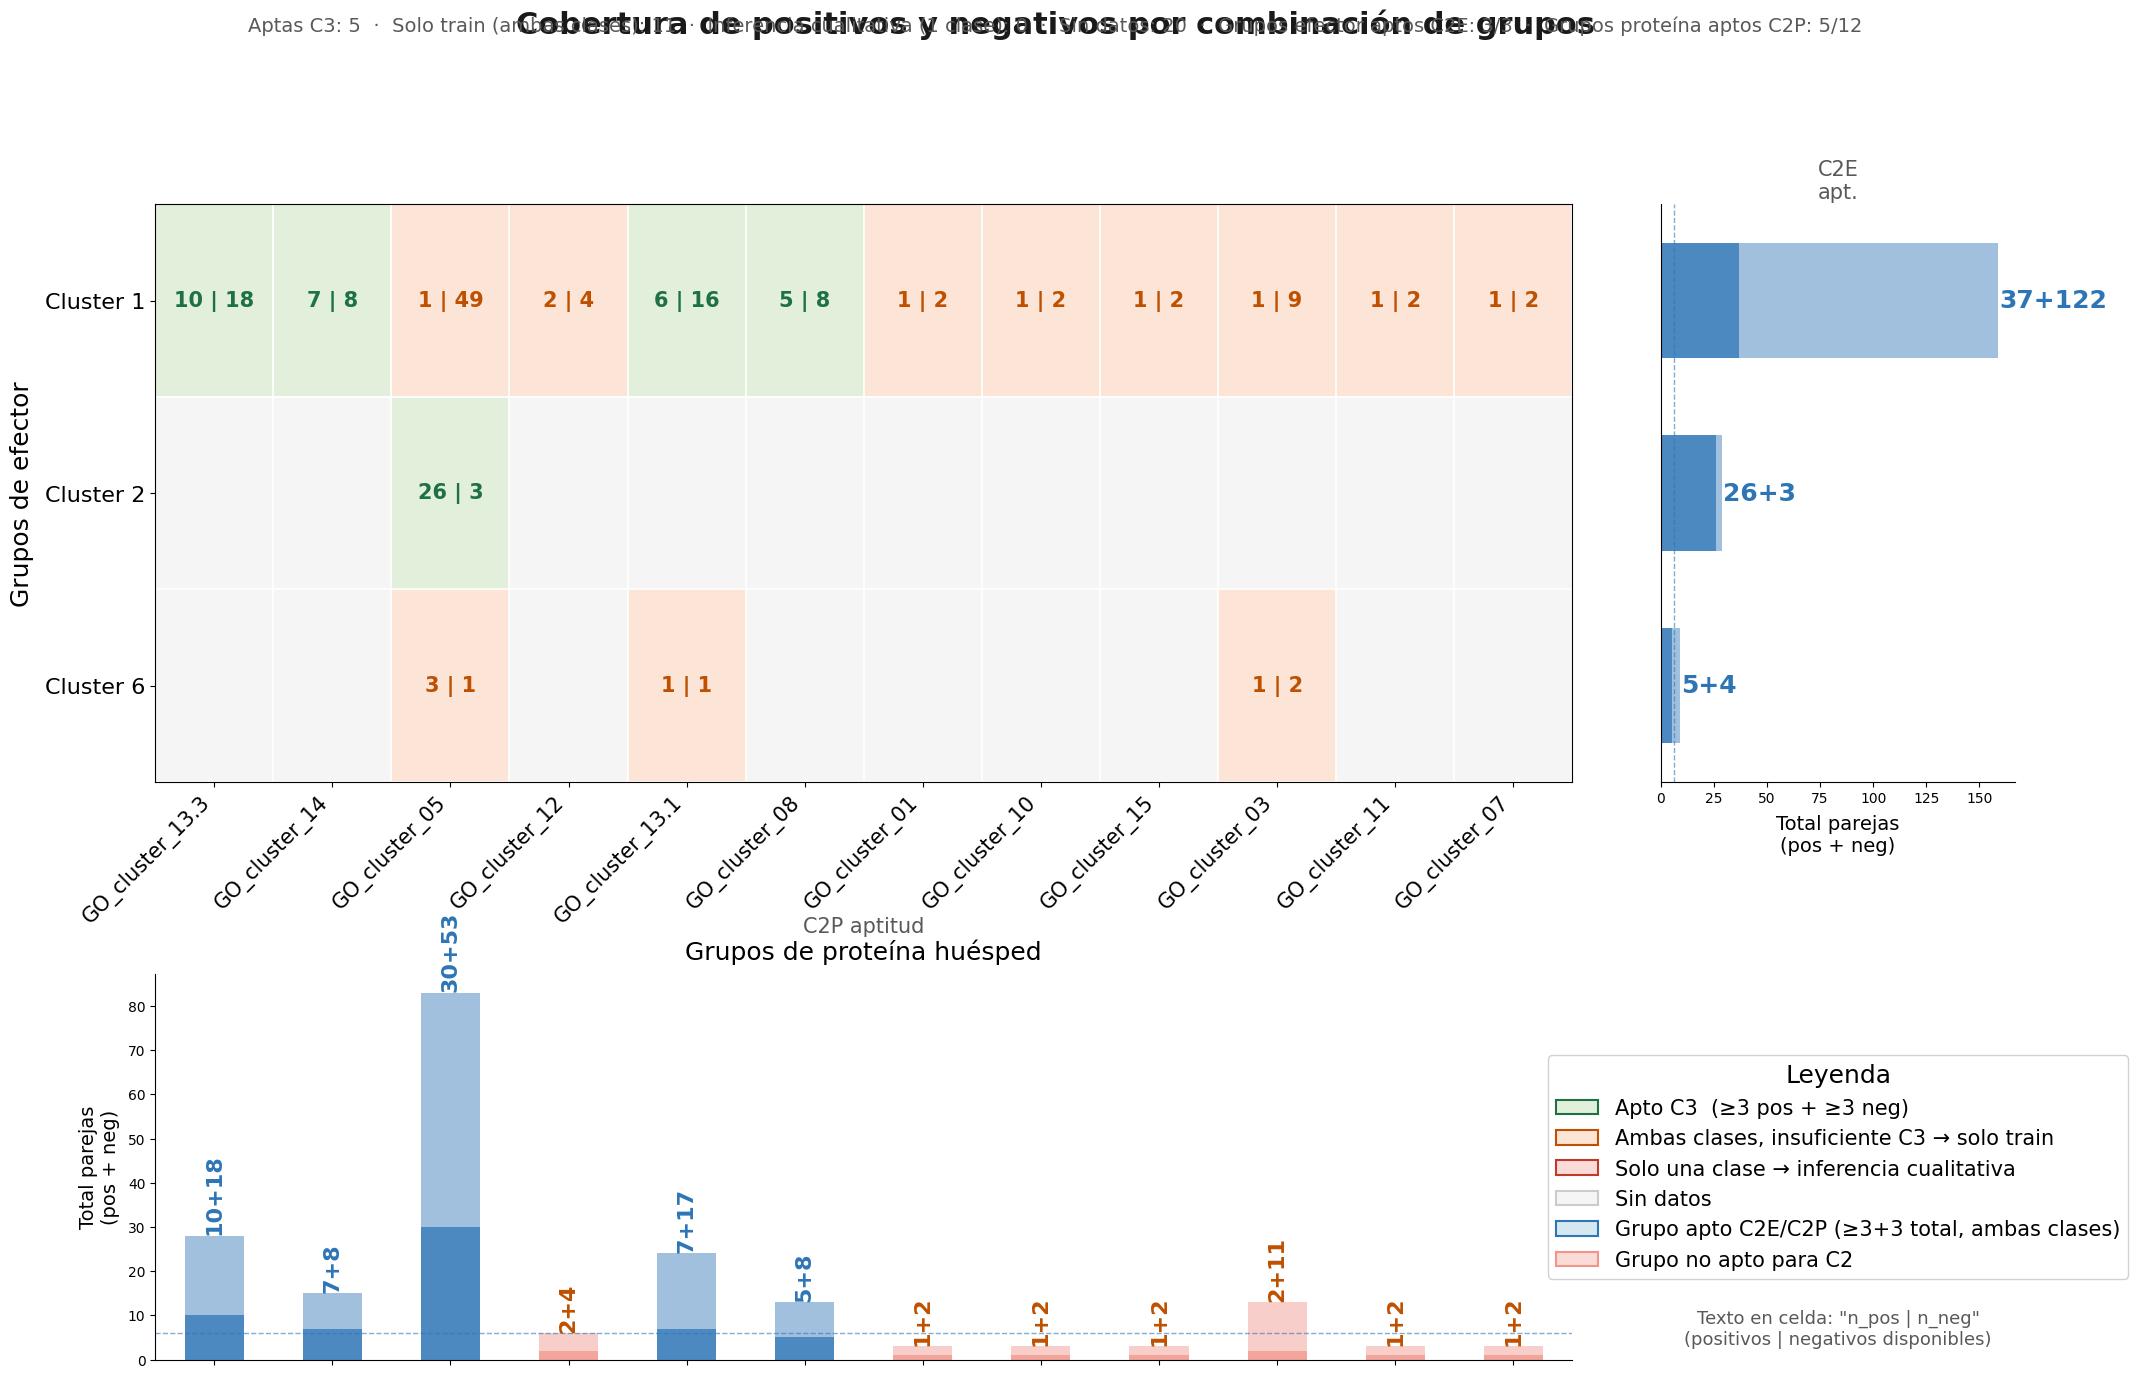

In [31]:
plot_coverage_heatmap(
    df=pos_neg_interactions_final, 
    effector_group_col="Effector_Group", 
    protein_group_col="Protein_Group",
    label_col="Label",
    save_path="heatmap_pos_neg_nivelc3_g13sep_filtro_estricto.png"
)

Repetimos las distribuciones de proteínas y efectores individuales

##### Distribución de proteínas individuales en el nivel C3 tras filtrar aquellas que no tienen representación positiva y negativa

Total de proteínas positivas: 68
Total de proteínas negativas: 129
Total de proteínas en el entrenamiento: 68 + 129 = 197


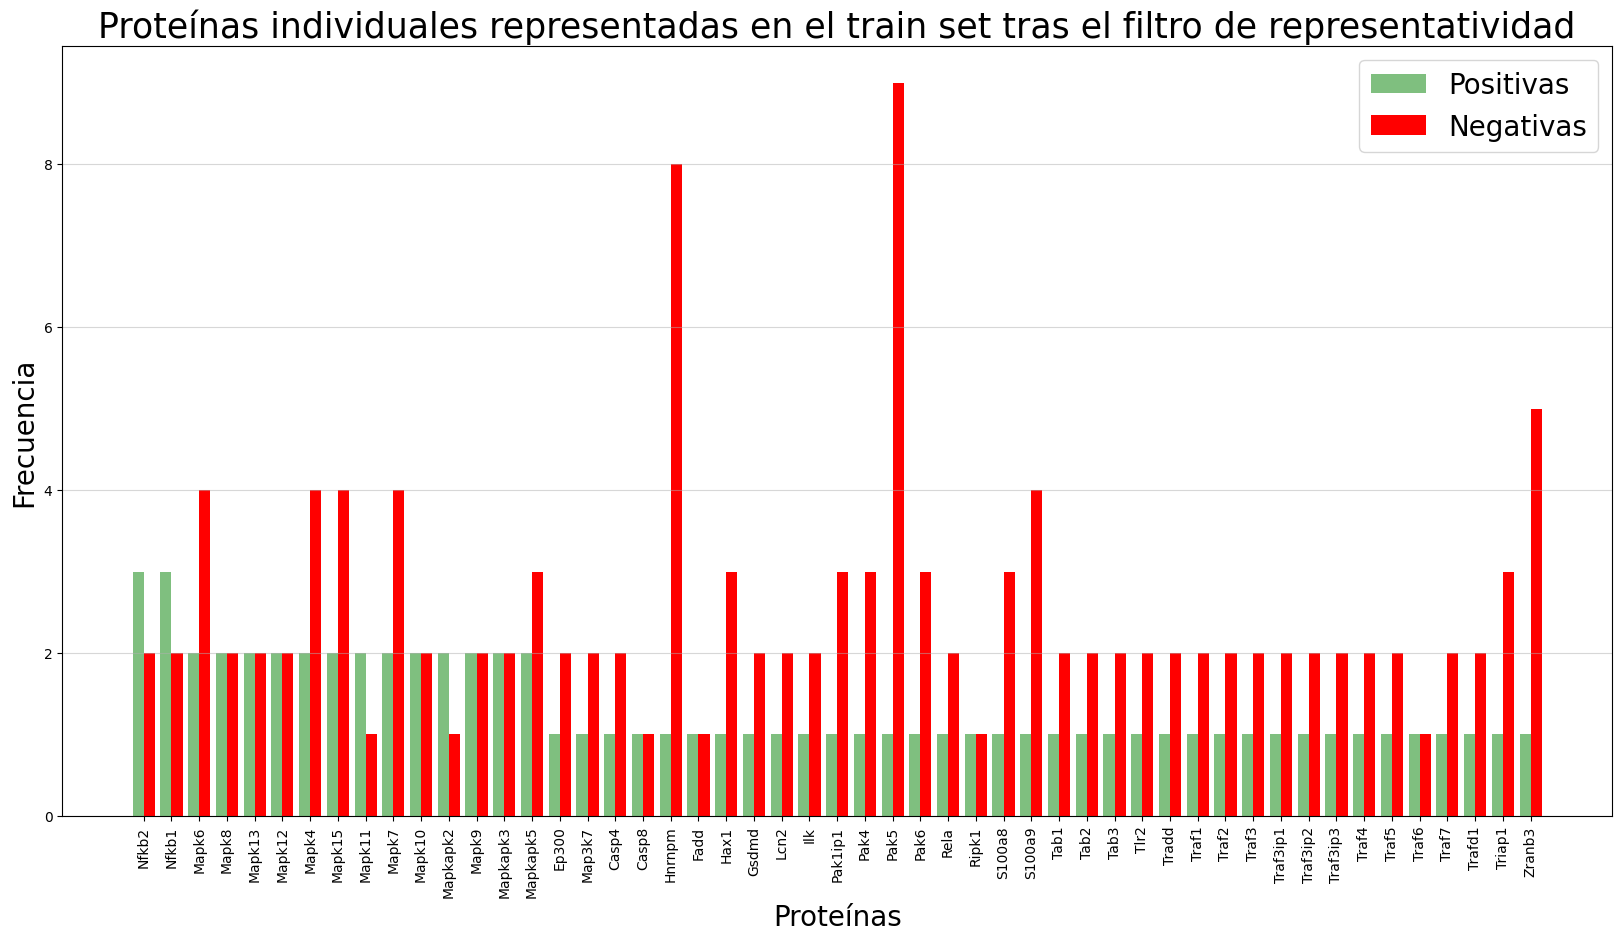

In [55]:
pos_prot_estricto = pos_interactions_f["Protein"]
print(f"Total de proteínas positivas: {len(pos_prot_estricto)}")
neg_prot_estricto = neg_interactions_f["Protein"]
print(f"Total de proteínas negativas: {len(neg_prot_estricto)}")
print(f"Total de proteínas en el entrenamiento: {len(pos_prot_estricto)} + {len(neg_prot_estricto)} = {len(pos_prot_estricto) + len(neg_prot_estricto)}")
pos_prot_freq_estricto = pos_prot_estricto.value_counts()
neg_prot_freq_estricto = neg_prot_estricto.value_counts()
draw_group_distribution(pos_prot_freq_estricto, neg_prot_freq_estricto, 'distribucion_prot_pos_neg_train_nivelc3_filtrado_g13sep.png', pos_color="green", neg_color="red", title="Proteínas individuales representadas en el train set tras el filtro de representatividad", x_label="Proteínas")

##### Distribución de efectores individuales en el nivel C3 tras filtrar aquellos que no tenían representación positiva y negativa a la vez

Total de efectores positivos: 68
Total de efectores negativos: 129
Total de efectores en el entrenamiento: 68 + 129 = 197


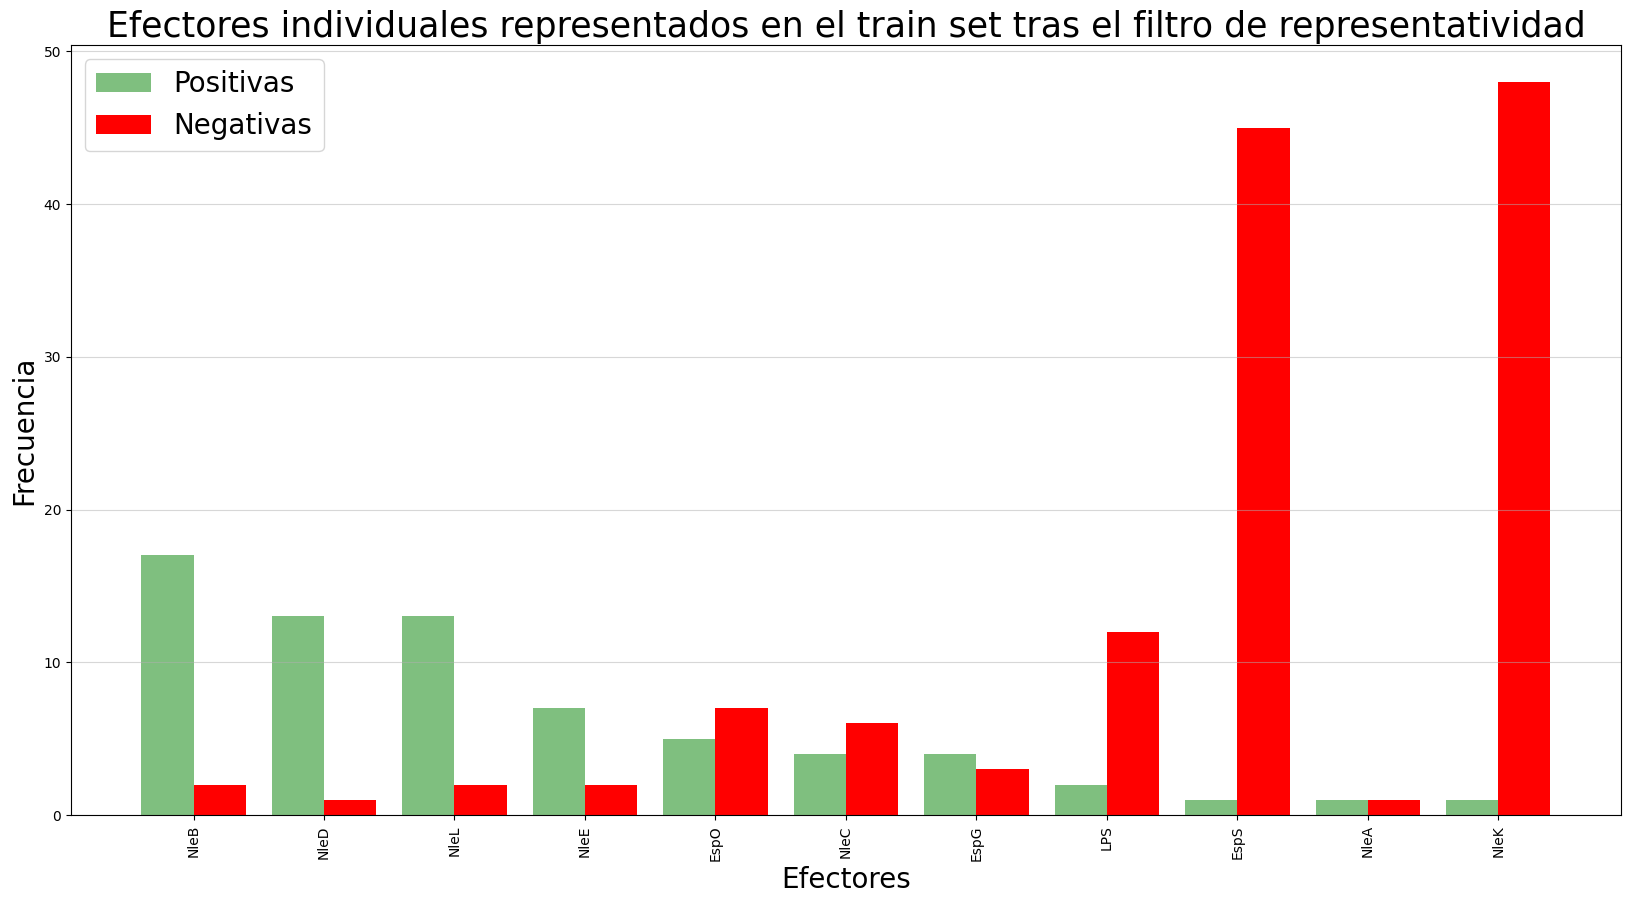

In [56]:
pos_ef_estricto = pos_interactions_f["Effector"]
print(f"Total de efectores positivos: {len(pos_ef_estricto)}")
neg_ef_estricto = neg_interactions_f["Effector"]
print(f"Total de efectores negativos: {len(neg_ef_estricto)}")
print(f"Total de efectores en el entrenamiento: {len(pos_ef_estricto)} + {len(neg_ef_estricto)} = {len(pos_ef_estricto) + len(neg_ef_estricto)}")
pos_ef_freq_estricto = pos_ef_estricto.value_counts()
neg_ef_freq_estricto = neg_ef_estricto.value_counts()
draw_group_distribution(pos_ef_freq_estricto, neg_ef_freq_estricto, 'distribucion_ef_pos_neg_train_nivelc3_filtrado_g13sep.png', pos_color="green", neg_color="red", title="Efectores individuales representados en el train set tras el filtro de representatividad", x_label="Efectores")

### Sin agrupación funcional de efectores

En vistas a los resultados después de la validación cruzada, como el grupo 1 de efectores (los de inflamación) está siendo problemático, hemos replanteado eliminar la agrupación funcional de los efectores. Al tratarse de efectores muy distintos y haber hecho una agrupación muy superficial, tiene lógica entrenar un modelo en el que no se tengan en cuenta estos grupos. 

Lo primero que vamos a hacer es repetir el heatmap como si cada efector fuese su propio grupo y ver cómo quedan las distribuciones.

/home/jovyan/TFG/plot_coverage_heatmap.py:382: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figura guardada en: heatmap_pos_neg_g13sep_no_ef_groups.png

── Resumen de aptitud por escenario ──────────────────────────────
  C3  : 0 combinaciones aptas (verde)
  Train only: 9 combinaciones (naranja, ambas clases, <3)
  Inf. cualitativa: 332 combinaciones (rojo, solo 1 clase)
  Sin datos: 307 combinaciones (gris)
  C2E : 1/24 grupos de efector aptos
  C2P : 1/27 grupos de proteína aptos
  ⚠️  Grupos efector NO aptos C2E: ['NleD', 'EspM', 'NleB', 'EspH', 'NleF', 'EspL', 'EspG', 'Map', 'EspO', 'NleE', 'EspF', 'EspT', 'EscF', 'pORF8', 'Tir', 'NleC', 'NleA', 'NleH', 'NleO', 'NleK', 'LPS', 'EspS', 'EspZ']
  ⚠️  Grupos proteína NO aptos C2P: ['GO_cluster_07', 'GO_cluster_16', 'GO_cluster_13.3', 'GO_cluster_14', 'GO_cluster_13.1', 'GO_cluster_12', 'GO_cluster_11', 'GO_cluster_20', 'GO_cluster_17', 'GO_cluster_09', 'GO_cluster_13.2', 'GO_cluster_08', 'GO_cluster_10', 'GO_cluster_23', 'GO_cluster_19', 'GO_cluster_06', 'GO_cluster_01', 'GO_cluster_24', 'GO_cluster_15', 'GO_cluster_03', 'GO

(<Figure size 2200x1400 with 4 Axes>,
 (<Axes: xlabel='Grupos de proteína huésped', ylabel='Grupos de efector'>,
  <Axes: title={'center': 'C2E\napt.'}, xlabel='Total parejas\n(pos + neg)'>,
  <Axes: title={'center': 'C2P aptitud'}, ylabel='Total parejas\n(pos + neg)'>,
  <Axes: >),
 {'n_cells_C3_apt': 0,
  'n_cells_train_only': 9,
  'n_cells_one_class': 332,
  'n_cells_empty': 307,
  'n_effector_groups_C2E': 1,
  'n_protein_groups_C2P': 1,
  'effector_apt_C2E': ['NleL'],
  'effector_nonapt_C2E': ['NleD',
   'EspM',
   'NleB',
   'EspH',
   'NleF',
   'EspL',
   'EspG',
   'Map',
   'EspO',
   'NleE',
   'EspF',
   'EspT',
   'EscF',
   'pORF8',
   'Tir',
   'NleC',
   'NleA',
   'NleH',
   'NleO',
   'NleK',
   'LPS',
   'EspS',
   'EspZ'],
  'protein_apt_C2P': ['GO_cluster_05'],
  'protein_nonapt_C2P': ['GO_cluster_07',
   'GO_cluster_16',
   'GO_cluster_13.3',
   'GO_cluster_14',
   'GO_cluster_13.1',
   'GO_cluster_12',
   'GO_cluster_11',
   'GO_cluster_20',
   'GO_cluster_17',
  

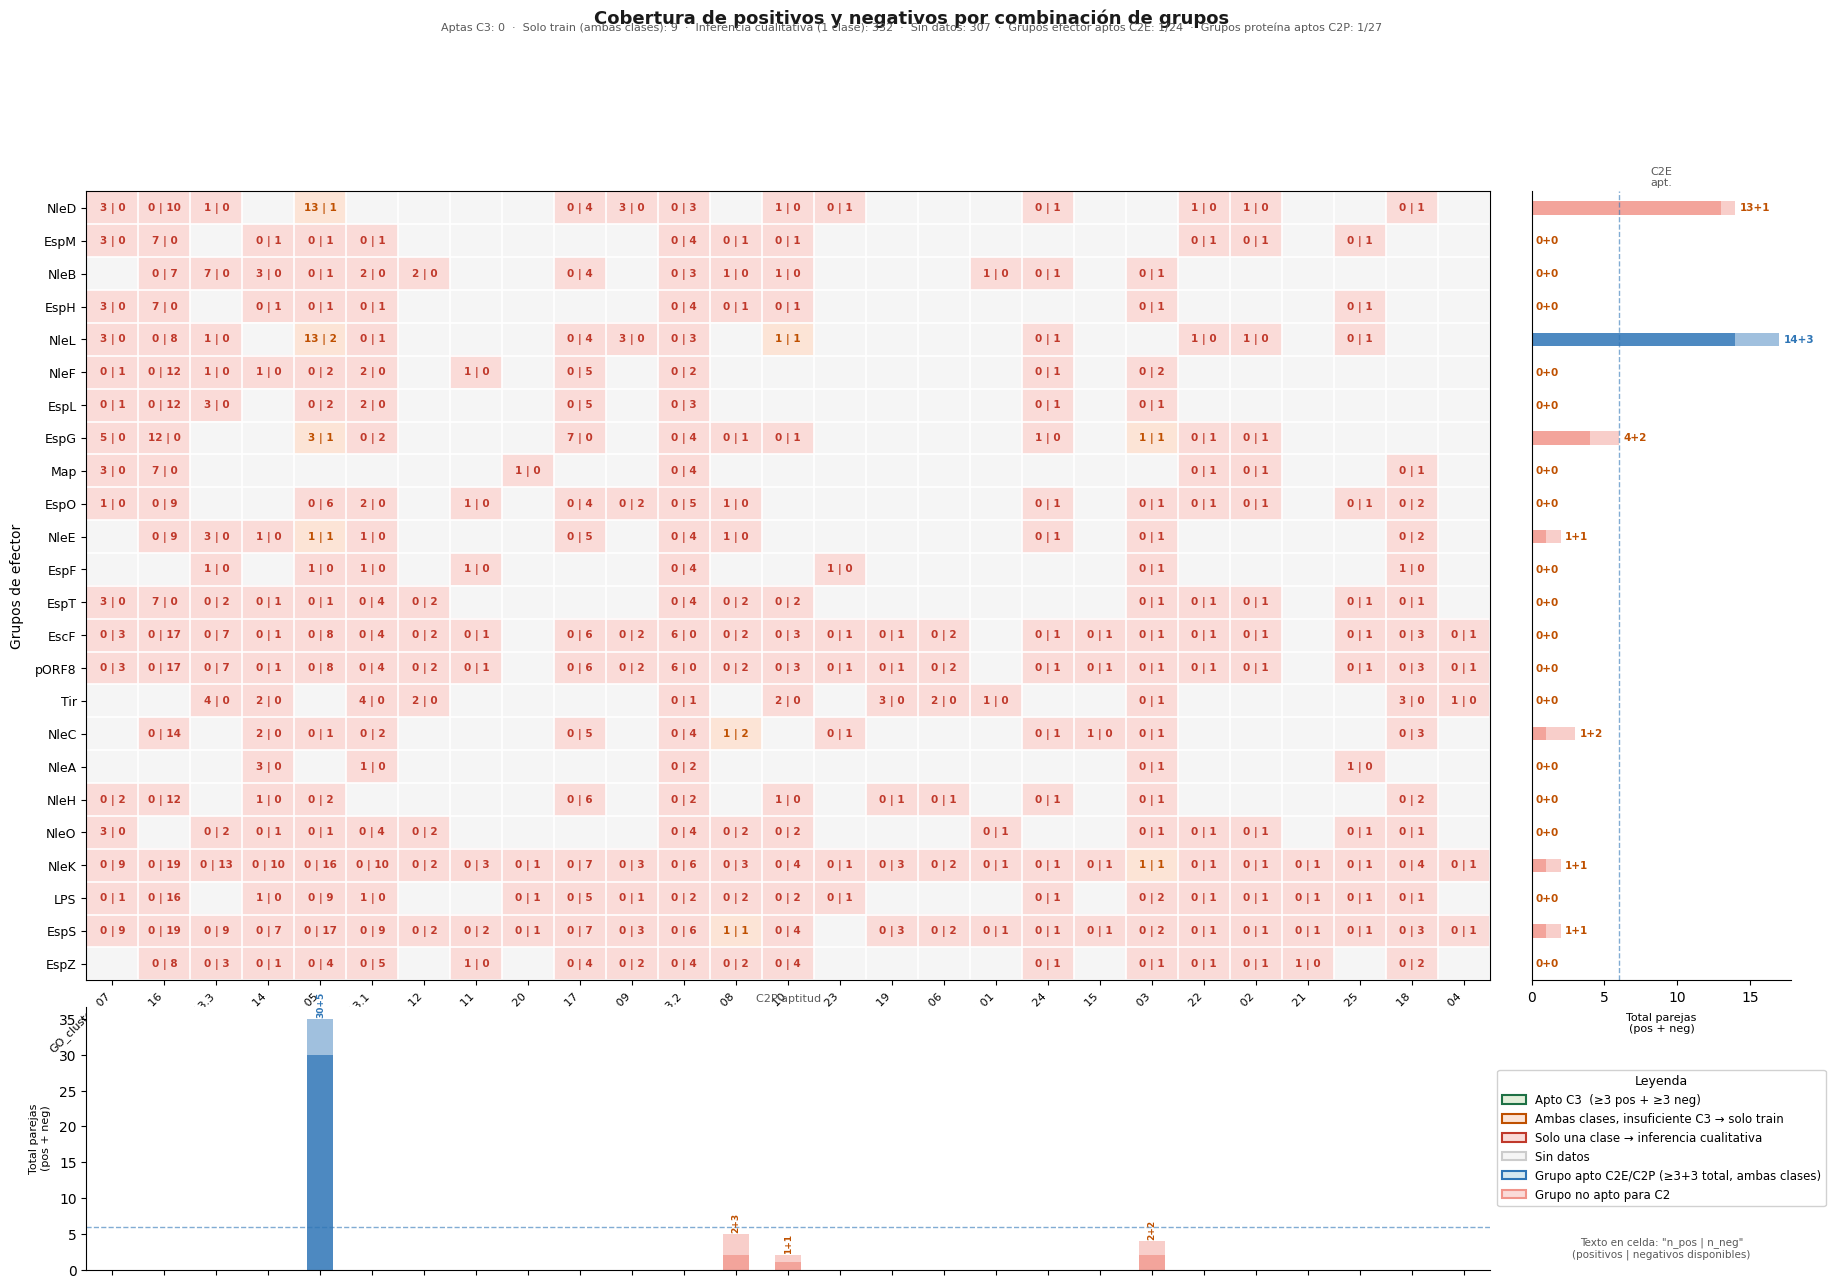

In [25]:
plot_coverage_heatmap(
    df=pos_neg_interactions, 
    effector_group_col="Effector", 
    protein_group_col="Protein_Group",
    label_col="Label",
    save_path="heatmap_pos_neg_g13sep_no_ef_groups.png"
)

# Distribuciones de proteínas y efectores sin agrupar

Vamos a hacer un caso adicional en el que ejecutaremos la validación cruzada sin agrupar los efectores ni las proteínas. Seguiremos manteniendo el nivel estricto, con lo que tendremos que asegurarnos de que no haya en el conjunto de entrenamiento proteínas o efectores que no tengan representación tanto en positivo como en negativo.

Observamos la distribución inicial de proteínas en positivo y negativo.

Total de proteínas positivas: 217
Total de proteínas negativas: 798
Total de proteínas en el entrenamiento: 217 + 798 = 1015


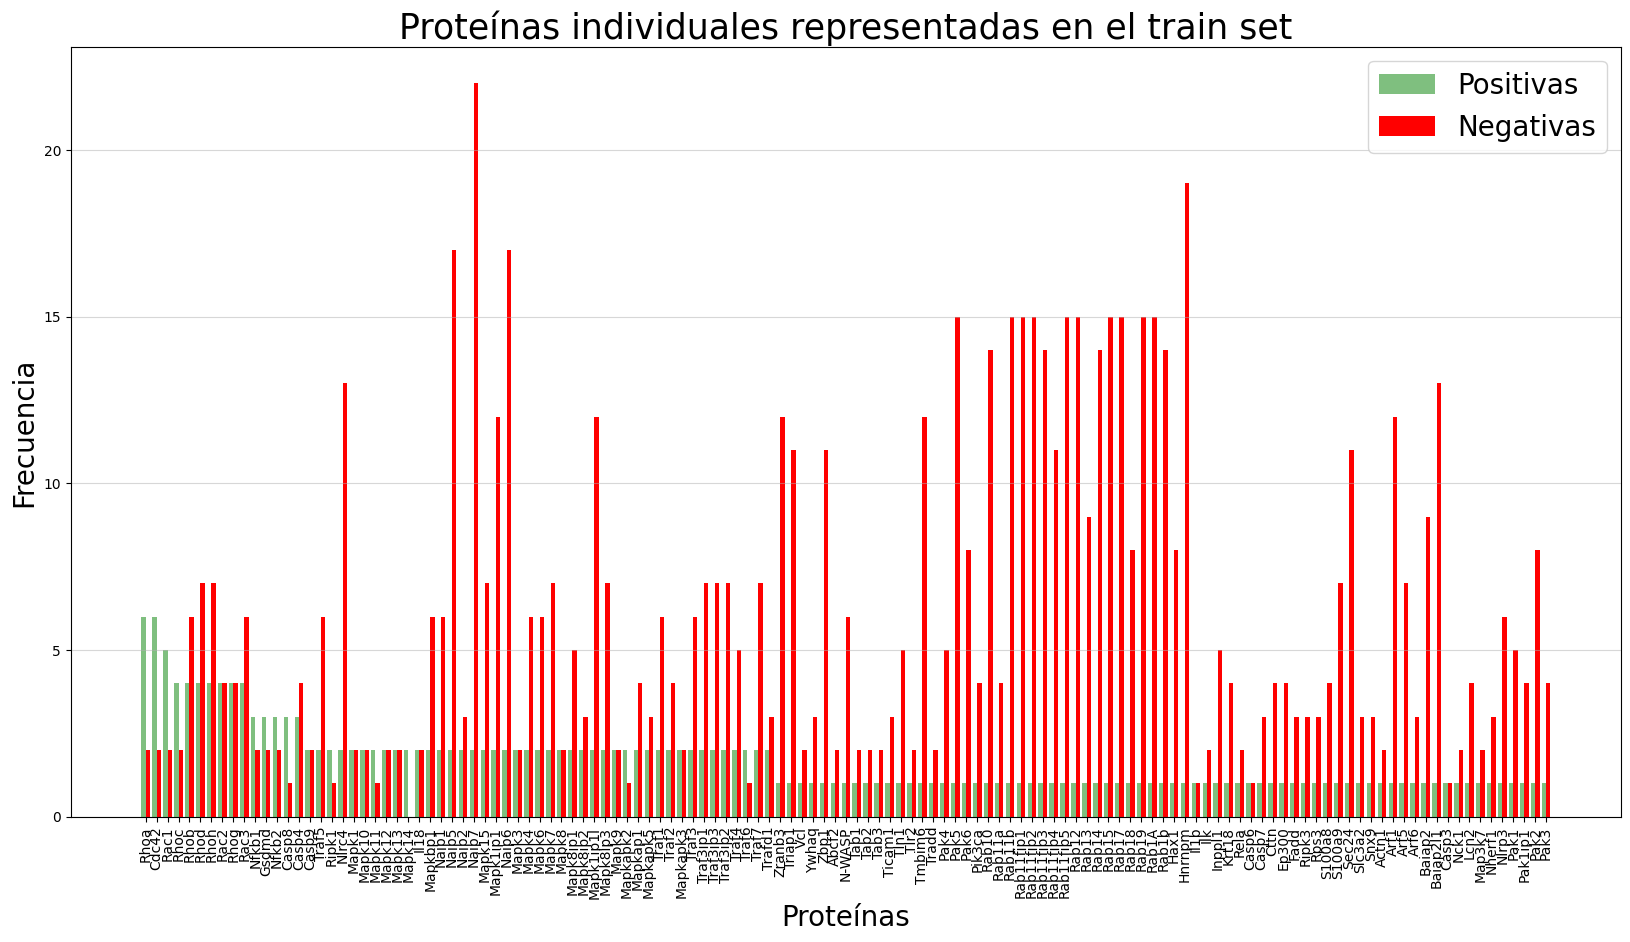

In [16]:
pos_prot_sin_agrupar = pos_interactions["Protein"]
print(f"Total de proteínas positivas: {len(pos_prot_sin_agrupar)}")
neg_prot_sin_agrupar = neg_interactions["Protein"]
print(f"Total de proteínas negativas: {len(neg_prot_sin_agrupar)}")
print(f"Total de proteínas en el entrenamiento: {len(pos_prot_sin_agrupar)} + {len(neg_prot_sin_agrupar)} = {len(pos_prot_sin_agrupar) + len(neg_prot_sin_agrupar)}")
pos_prot_freq_sin_agrupar = pos_prot_sin_agrupar.value_counts()
neg_prot_freq_sin_agrupar = neg_prot_sin_agrupar.value_counts()
draw_group_distribution(pos_prot_freq_sin_agrupar, neg_prot_freq_sin_agrupar, 'distribucion_prot_pos_neg_train_sin_agrupar.png', pos_color="green", neg_color="red", title="Proteínas individuales representadas en el train set", x_label="Proteínas")

Total de efectores positivos: 217
Total de efectores negativos: 798
Total de efectores en el entrenamiento: 217 + 798 = 1015


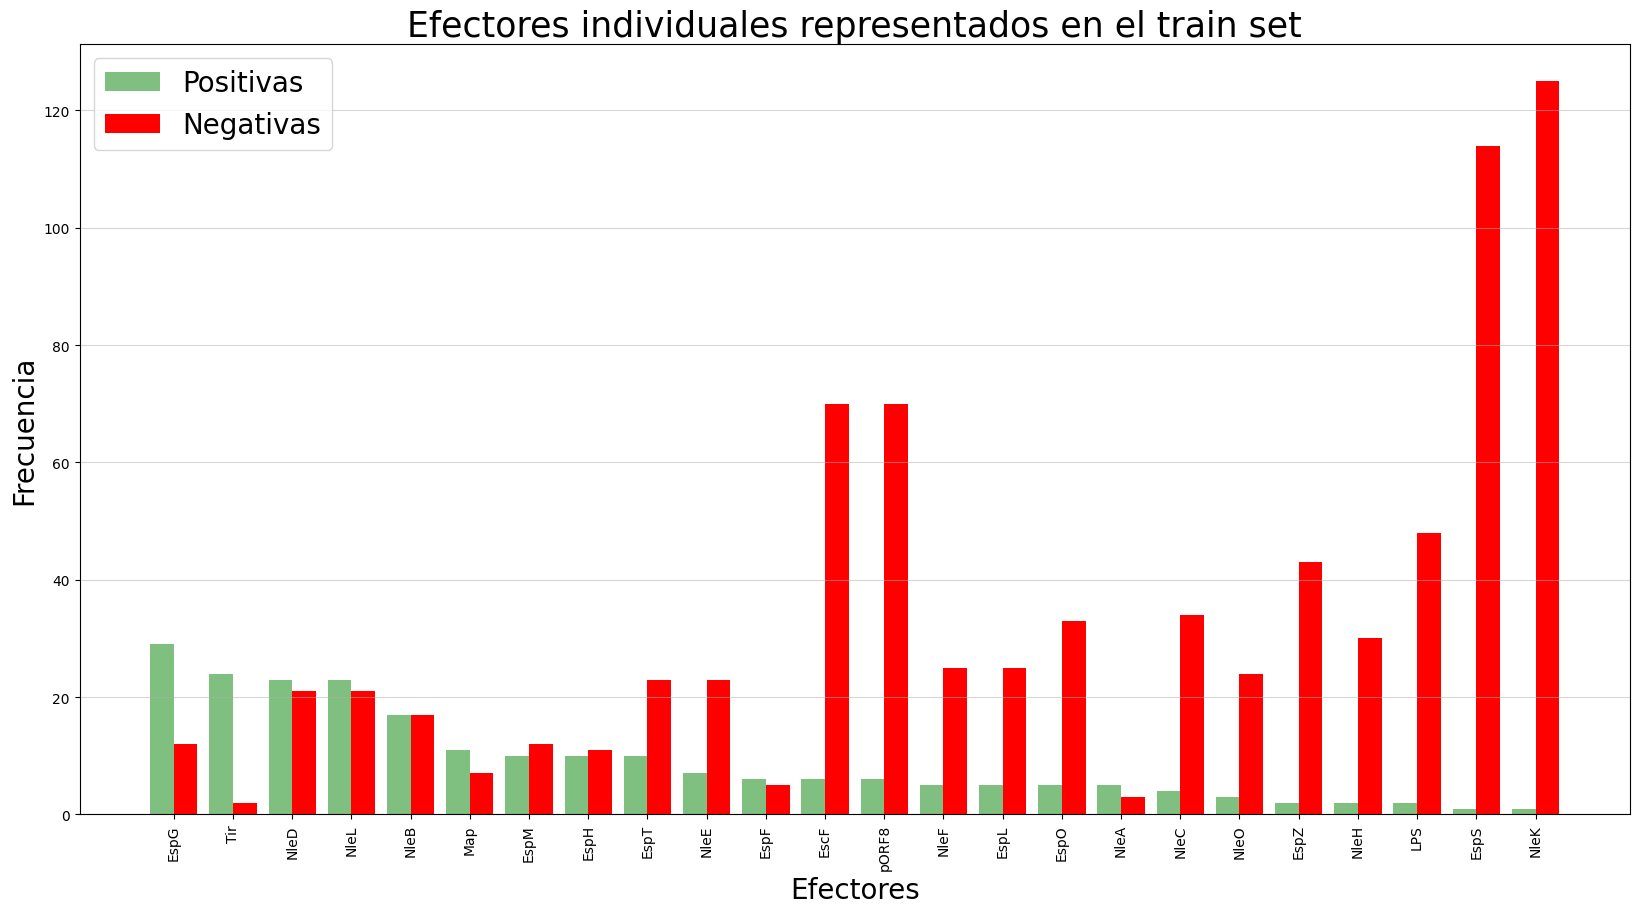

In [17]:
pos_ef_sin_agrupar = pos_interactions["Effector"]
print(f"Total de efectores positivos: {len(pos_ef_sin_agrupar)}")
neg_ef_sin_agrupar = neg_interactions["Effector"]
print(f"Total de efectores negativos: {len(neg_ef_sin_agrupar)}")
print(f"Total de efectores en el entrenamiento: {len(pos_ef_sin_agrupar)} + {len(neg_ef_sin_agrupar)} = {len(pos_ef_sin_agrupar) + len(neg_ef_sin_agrupar)}")
pos_ef_freq_sin_agrupar = pos_ef_sin_agrupar.value_counts()
neg_ef_freq_sin_agrupar = neg_ef_sin_agrupar.value_counts()
draw_group_distribution(pos_ef_freq_sin_agrupar, neg_ef_freq_sin_agrupar, 'distribucion_ef_pos_neg_train_sin_agrupar.png', pos_color="green", neg_color="red", title="Efectores individuales representados en el train set", x_label="Efectores")

#### Nivel estricto

Igual que antes nos aseguramos de que todas las proteínas y todos los efectores tengan al menos una representación positiva y una representación negativa, para que el modelo no aprenda por el criterio que no debe.

De los efectores solo va a hacer falta eliminar EspS y NleK, por tener demasiadas interacciones negativas y tan solo una positiva.

In [18]:
def filtrar_interactuantes_bidireccionales(df, col_prot='Protein', col_efector='Effector', col_label='Label'):
    """
    Filtra el DataFrame para retener solo las filas donde tanto la proteína 
    como el efector aparecen asociados a ambos labels (0 y 1).
    """
    pasada = 0
    while True:
        n_inicial = len(df)
        # 1. Identificar proteínas que tienen ambos labels (0 y 1)
        prots_bidireccionales = df.groupby(col_prot)[col_label].nunique()
        prots_bidireccionales = prots_bidireccionales[prots_bidireccionales == 2].index
        
        # 2. Identificar efectores que tienen ambos labels (0 y 1)
        efectores_bidireccionales = df.groupby(col_efector)[col_label].nunique()
        efectores_bidireccionales = efectores_bidireccionales[efectores_bidireccionales == 2].index
        
        # 3. Aplicar filtro: solo filas donde proteina Y efector están en los sets anteriores
        df = df[df['Protein'].isin(prots_bidireccionales) & df['Effector'].isin(efectores_bidireccionales)]
        
        pasada += 1
        n_final = len(df)
        print(f"Pasada {pasada}: {n_inicial} -> {n_final} filas")
        
        if n_inicial == n_final:
            print("✅ Estabilidad total alcanzada: Celdas e individuos son mixtos.")
            break
        
    return df

Antes de ejecutar el filtro, es necesario quitar algunas muestras que AlphaFold3 no fue capaz de ejecutar y de las que no vamos a poder disponer.

In [19]:
from pathlib import Path

incomplete_samples = set()
OUTPUT_AF3 = Path("/home/jovyan/TFG/output_Efectores_alphafold_all")

for sample in OUTPUT_AF3.iterdir():
    if sample.is_dir() and ".ipynb_checkpoints" not in sample.name:
        if not (sample / "TERMS_OF_USE.md") in sample.iterdir():
            # Nos quedamos con el nombre limpio y lo guardamos en la lista
            parts = sample.name.split('_')
            clean_name = "_".join(parts[:2])
            incomplete_samples.add(clean_name)

len(incomplete_samples)
incomplete_samples

{'B2RWS6_EspN',
 'B2RWS6_NleL',
 'P26039_EspL',
 'P26039_EspN',
 'P26039_NleL',
 'P26039_Tir'}

In [21]:
train_sin_agrupar = pd.concat([pos_interactions, neg_interactions])
train_sin_agrupar['Label'] = train_sin_agrupar['Is_Connected'].astype(int)
# Eliminamos los dos efectores que había mencionado
train_sin_agrupar = train_sin_agrupar[~(train_sin_agrupar['Effector'].isin(['EspS', 'NleK']))]
# Y eliminamos las muestras que no están completas
# Para eso necesitamos crear una columna Sample_name mapeando antes los nombres de las proteínas tal cual están en Uniprot
# Mapeo los nombres de Uniprot
uniprot_equivalences = pd.read_csv("/home/jovyan/TFG/Interacciones_EffectorProteina_LiteratureOnly_Ordenadas_NleG.csv", sep=",")
prot_id = pd.Series(uniprot_equivalences.Protein.values, index=uniprot_equivalences.ProteinGeneName).to_dict()
train_sin_agrupar["Protein_ID"] = train_sin_agrupar["Protein"].map(prot_id)
# Creo la columna Sample_names
train_sin_agrupar["Sample_name"] = train_sin_agrupar["Protein_ID"] + "_" + train_sin_agrupar["Effector"]
# Elimino del entrenamiento las muestras incompletas
train_sin_agrupar = train_sin_agrupar[~train_sin_agrupar["Sample_name"].isin(incomplete_samples)]
train_sin_agrupar

,Effector,Protein,Shortest_Path,Shared_Connections,Pathways_Shared,Is_Connected,Interaction_Score,Effector_Group,Protein_Group,Label,Protein_ID,Sample_name
0,NleD,Mapk14,1,13,1,True,0.603571,Cluster 2,GO_cluster_07,1,P47811,P47811_NleD
1,EspM,Rhoc,1,3,3,True,0.539286,Cluster 0,GO_cluster_16,1,Q62159,Q62159_EspM
2,NleB,Ripk1,1,13,0,True,0.528571,Cluster 1,GO_cluster_13.3,1,Q60855,Q60855_NleB
3,NleB,Nfkb1,1,2,3,True,0.517857,Cluster 1,GO_cluster_14,1,P25799,P25799_NleB
4,EspH,Rac2,1,2,3,True,0.517857,Cluster 0,GO_cluster_16,1,Q05144,Q05144_EspH
...,...,...,...,...,...,...,...,...,...,...,...,...
4767,pORF8,Rab11fip5,5,0,0,False,0.050000,Cluster 4,GO_cluster_17,0,Q8R361,Q8R361_pORF8
4768,pORF8,Tmbim6,5,0,0,False,0.050000,Cluster 4,GO_cluster_10,0,Q3TX81,Q3TX81_pORF8
4769,pORF8,Rab17,5,0,0,False,0.050000,Cluster 4,GO_cluster_16,0,P35292,P35292_pORF8
4770,pORF8,Rab11b,5,0,0,False,0.050000,Cluster 4,GO_cluster_16,0,P46638,P46638_pORF8


In [22]:
train_sin_agrupar_filtrado = filtrar_interactuantes_bidireccionales(train_sin_agrupar)
train_sin_agrupar_filtrado

Pasada 1: 773 -> 665 filas
Pasada 2: 665 -> 643 filas
Pasada 3: 643 -> 641 filas
Pasada 4: 641 -> 641 filas
✅ Estabilidad total alcanzada: Celdas e individuos son mixtos.


,Effector,Protein,Shortest_Path,Shared_Connections,Pathways_Shared,Is_Connected,Interaction_Score,Effector_Group,Protein_Group,Label,Protein_ID,Sample_name
4,EspH,Rac2,1,2,3,True,0.517857,Cluster 0,GO_cluster_16,1,Q05144,Q05144_EspH
7,NleF,Casp4,1,1,3,True,0.496429,Cluster 3,GO_cluster_13.1,1,P70343,P70343_NleF
12,NleB,Traf5,1,2,2,True,0.442857,Cluster 1,GO_cluster_12,1,P70191,P70191_NleB
13,EspM,Rac2,1,2,2,True,0.442857,Cluster 0,GO_cluster_16,1,Q05144,Q05144_EspM
15,Map,Rac2,1,1,2,True,0.421429,Cluster 0,GO_cluster_16,1,Q05144,Q05144_Map
...,...,...,...,...,...,...,...,...,...,...,...,...
4767,pORF8,Rab11fip5,5,0,0,False,0.050000,Cluster 4,GO_cluster_17,0,Q8R361,Q8R361_pORF8
4768,pORF8,Tmbim6,5,0,0,False,0.050000,Cluster 4,GO_cluster_10,0,Q3TX81,Q3TX81_pORF8
4769,pORF8,Rab17,5,0,0,False,0.050000,Cluster 4,GO_cluster_16,0,P35292,P35292_pORF8
4770,pORF8,Rab11b,5,0,0,False,0.050000,Cluster 4,GO_cluster_16,0,P46638,P46638_pORF8


Repetimos ahora las distribuciones para asegurarnos de que se han filtrado bien.

In [23]:
pos_interactions_sin_agrupar_filtrado = train_sin_agrupar_filtrado[train_sin_agrupar_filtrado['Is_Connected'] == True]
print(f"Interacciones positivas tras el filtrado: {len(pos_interactions_sin_agrupar_filtrado)}")
neg_interactions_sin_agrupar_filtrado = train_sin_agrupar_filtrado[train_sin_agrupar_filtrado['Is_Connected'] == False]
print(f"Interacciones negativas tras el filtrado: {len(neg_interactions_sin_agrupar_filtrado)}")
print(f"Tamaño total del set de entrenamiento filtrado: {len(pos_interactions_sin_agrupar_filtrado) + len(neg_interactions_sin_agrupar_filtrado)}")

Interacciones positivas tras el filtrado: 135
Interacciones negativas tras el filtrado: 506
Tamaño total del set de entrenamiento filtrado: 641


Total de proteínas positivas: 135
Total de proteínas negativas: 506
Total de proteínas en el entrenamiento: 135 + 506 = 641


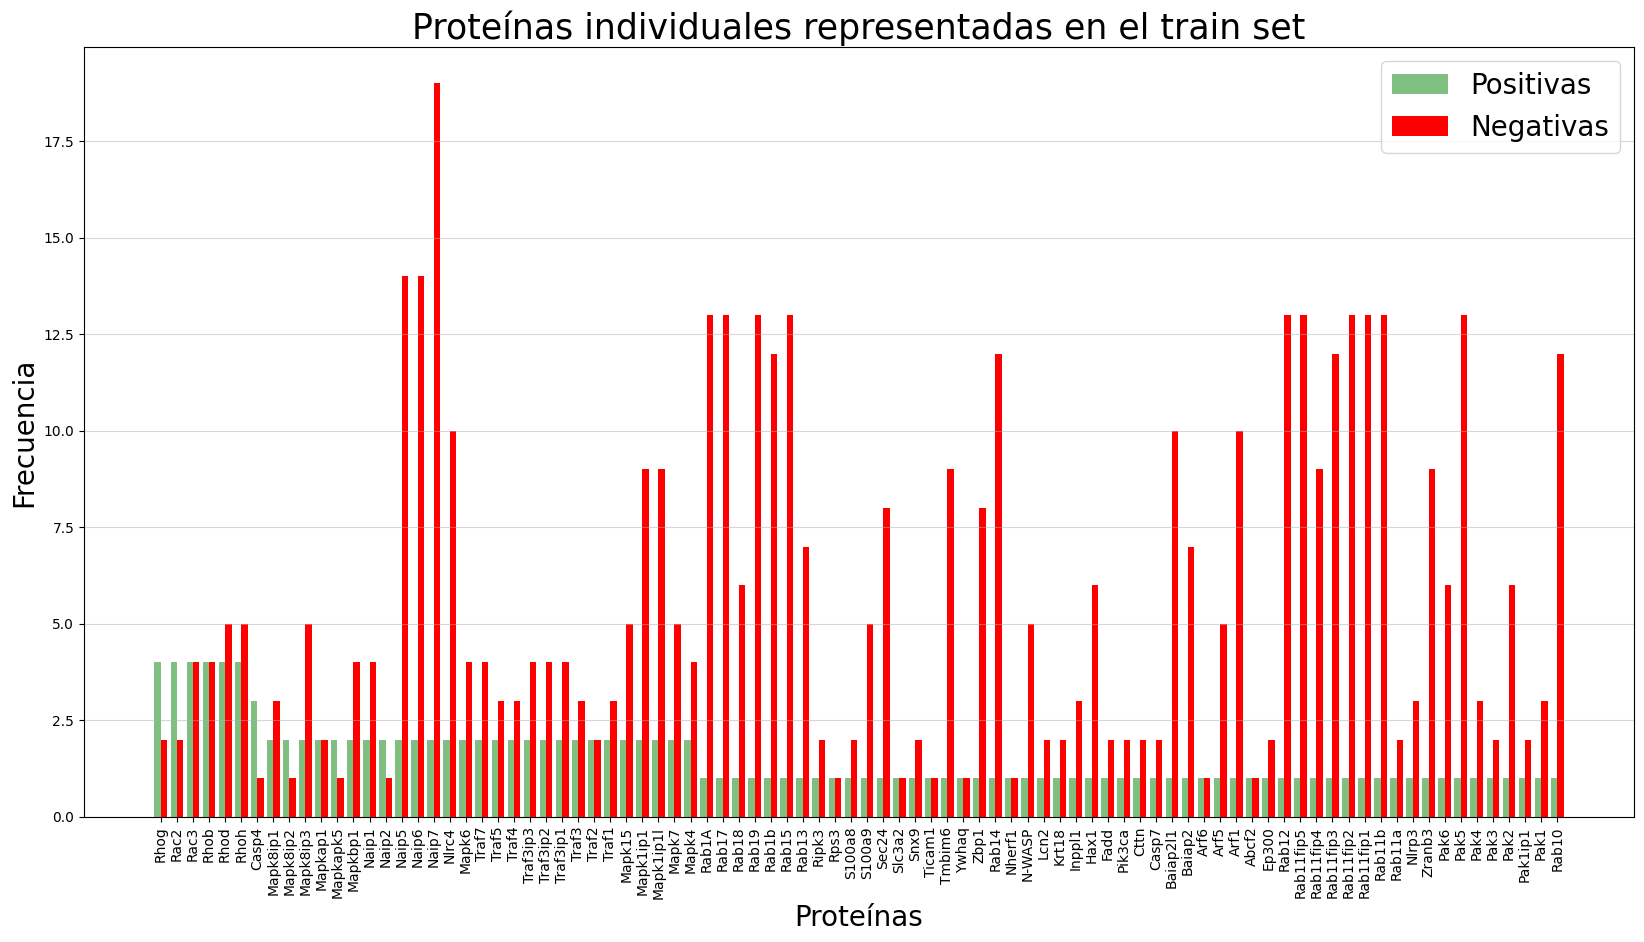

In [28]:
pos_prot_sin_agrupar_filtrado = pos_interactions_sin_agrupar_filtrado["Protein"]
print(f"Total de proteínas positivas: {len(pos_prot_sin_agrupar_filtrado)}")
neg_prot_sin_agrupar_filtrado = neg_interactions_sin_agrupar_filtrado["Protein"]
print(f"Total de proteínas negativas: {len(neg_prot_sin_agrupar_filtrado)}")
print(f"Total de proteínas en el entrenamiento: {len(pos_prot_sin_agrupar_filtrado)} + {len(neg_prot_sin_agrupar_filtrado)} = {len(pos_prot_sin_agrupar_filtrado) + len(neg_prot_sin_agrupar_filtrado)}")
pos_prot_freq_sin_agrupar_filtrado = pos_prot_sin_agrupar_filtrado.value_counts()
neg_prot_freq_sin_agrupar_filtrado = neg_prot_sin_agrupar_filtrado.value_counts()
draw_group_distribution(pos_prot_freq_sin_agrupar_filtrado, neg_prot_freq_sin_agrupar_filtrado, '/home/jovyan/TFG/CV_sin_agrupar/imagenes/distribucion_prot_pos_neg_train_sin_agrupar_estricto.png', pos_color="green", neg_color="red", title="Proteínas individuales representadas en el train set", x_label="Proteínas")

Total de efectores positivos: 135
Total de efectores negativos: 506
Total de efectores en el entrenamiento: 135 + 506 = 641


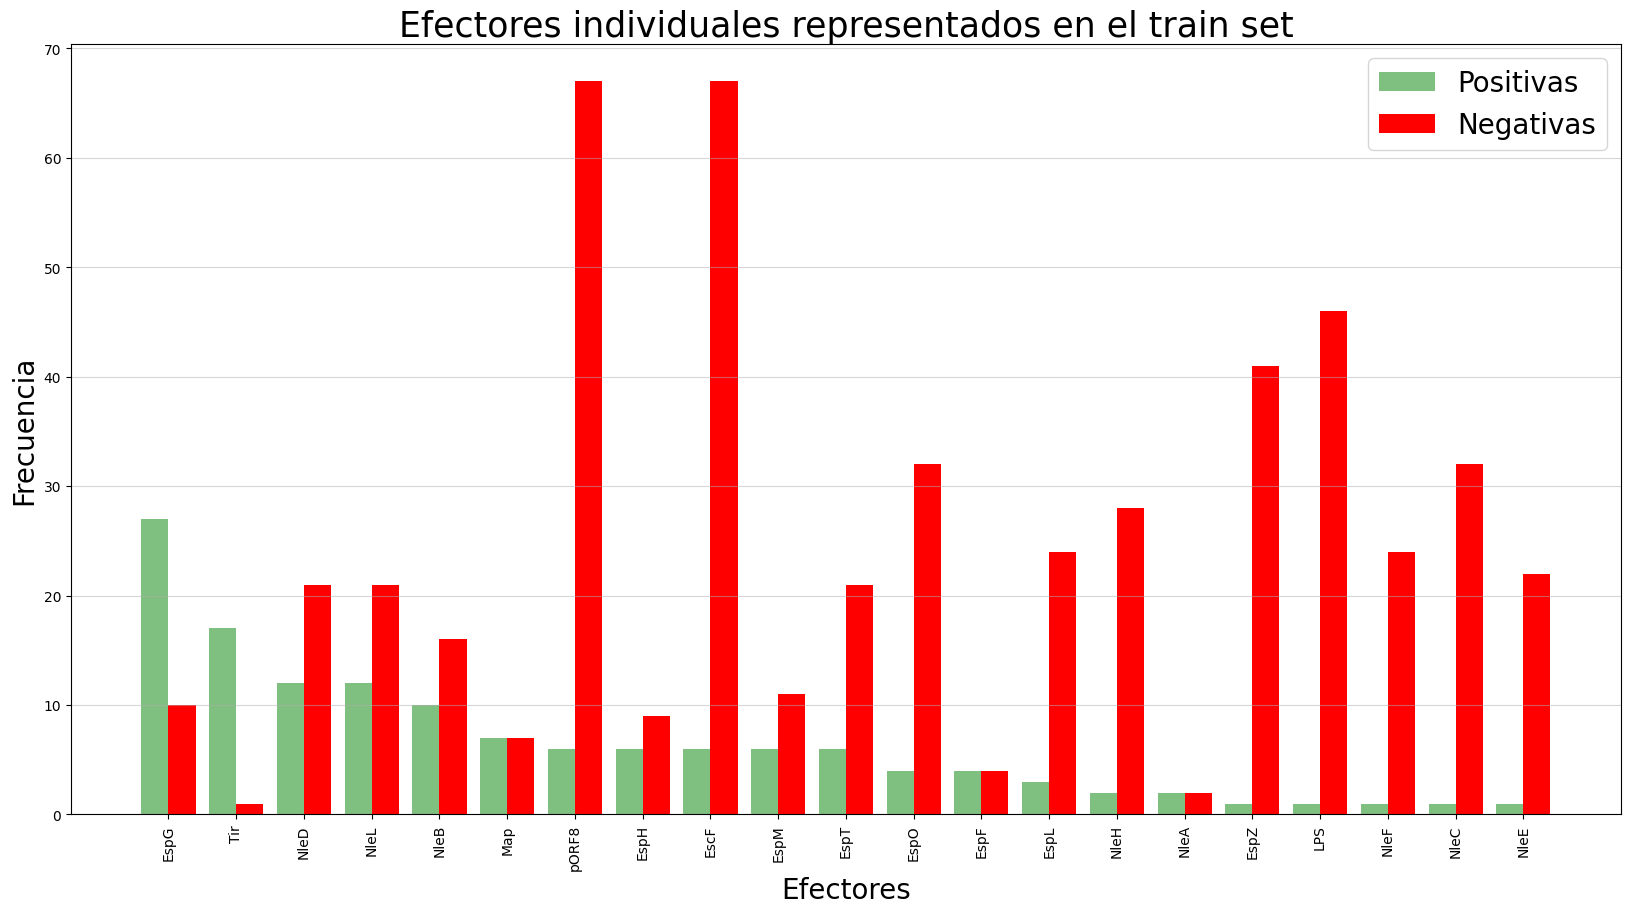

In [29]:
pos_ef_sin_agrupar_filtrado = pos_interactions_sin_agrupar_filtrado["Effector"]
print(f"Total de efectores positivos: {len(pos_ef_sin_agrupar_filtrado)}")
neg_ef_sin_agrupar_filtrado = neg_interactions_sin_agrupar_filtrado["Effector"]
print(f"Total de efectores negativos: {len(neg_ef_sin_agrupar_filtrado)}")
print(f"Total de efectores en el entrenamiento: {len(pos_ef_sin_agrupar_filtrado)} + {len(neg_ef_sin_agrupar_filtrado)} = {len(pos_ef_sin_agrupar_filtrado) + len(neg_ef_sin_agrupar_filtrado)}")
pos_ef_freq_sin_agrupar_filtrado = pos_ef_sin_agrupar_filtrado.value_counts()
neg_ef_freq_sin_agrupar_filtrado = neg_ef_sin_agrupar_filtrado.value_counts()
draw_group_distribution(pos_ef_freq_sin_agrupar_filtrado, neg_ef_freq_sin_agrupar_filtrado, '/home/jovyan/TFG/CV_sin_agrupar/imagenes/distribucion_ef_pos_neg_train_sin_agrupar_estricto.png', pos_color="green", neg_color="red", title="Efectores individuales representados en el train set", x_label="Efectores")

Guardamos este Data Frame de interacciones filtradas para poder utilizarlo en la validación cruzada.

In [26]:
train_sin_agrupar_filtrado.to_csv("/home/jovyan/TFG/CV_sin_agrupar/Interacciones_Entrenamiento_CV_sin_agrupar_estricto.csv", index=False)